# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 40     |  |
| :-------------|:-------------|
| Thomas Haak| 6472672 |
| Matthias Grablowitz| 6247261 |
| Chinming Zhu| 6325971 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Thomas Haak', 'Matthias Grablowitz','Chinming Zhu']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren sensor | 11:40 |
| Testen van algoritme | 12:00 |
| Algoritme bedacht in pauze| 13:45 |
| Iteratie 0 | 15:15 |
| Iteratie 1| 16:15 |
| Eindwerk laten zien aan TA | 17:00 |
| Alles inleveren inc feedback | 17:20 | 

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [40]
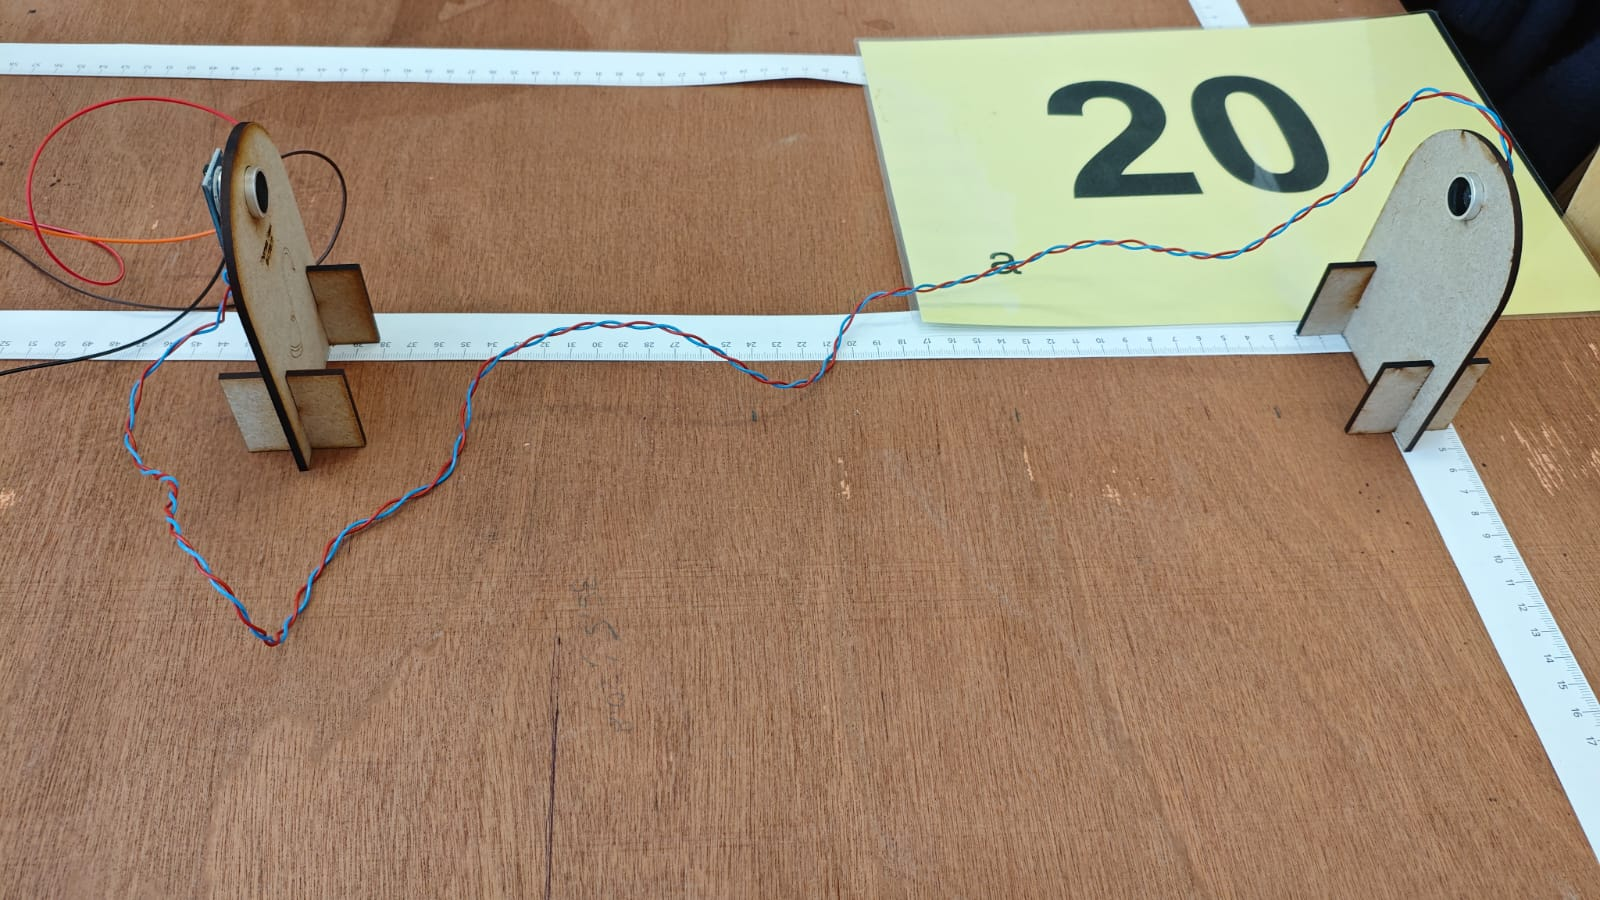

In [3]:
# verwerk hier jullie kalibratiemetingen

bits = [219, 530, 818, 1120, 1395, 1680, 1967]
afstand = [10, 20, 30, 40, 50, 60, 70]

def kalibratie_fit(bits, alpha, beta):
    return alpha*bits + beta

val, cov = curve_fit(kalibratie_fit, bits, afstand)
kal_alpha, kal_beta = val
u_alpha = np.sqrt(cov[0,0])
u_beta = np.sqrt(cov[0,0])

print("Kalibratiewaarden:")
print("Alpha = %.4f \u00B1 %.4f" %(kal_alpha, u_alpha))
print("Beta = %.4f \u00B1 %.4f" %(kal_beta, u_beta))

Kalibratiewaarden:
Alpha = 0.0345 ± 0.0002
Beta = 1.9405 ± 0.0002


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  43.55
1   0  30   0  20  42.62
2  40   0  30   0  41.55
3  30   0  20   0  41.34


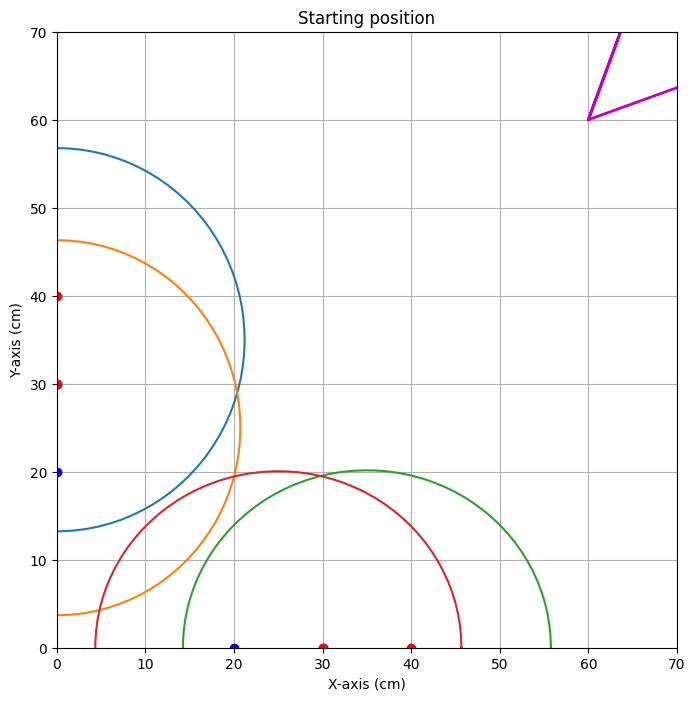


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.690


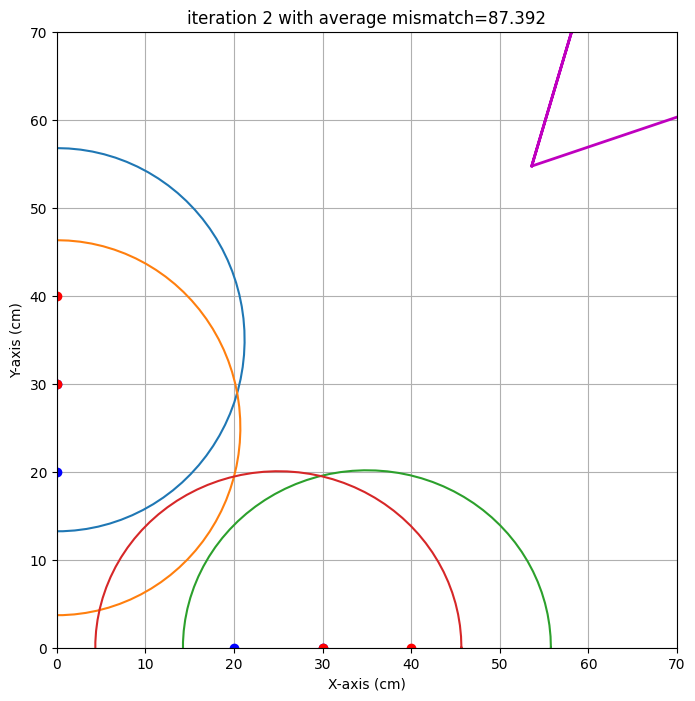

end iteration 2 with average mismatch=87.392


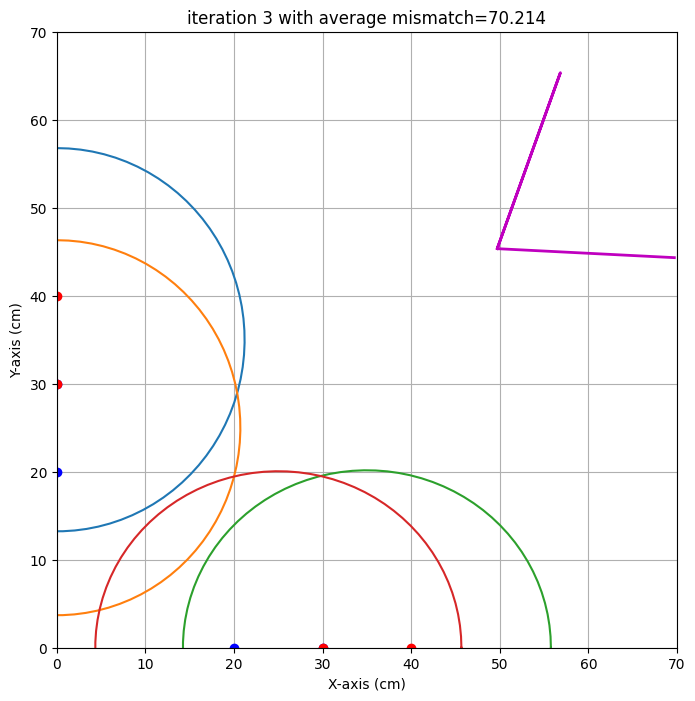

end iteration 3 with average mismatch=70.214


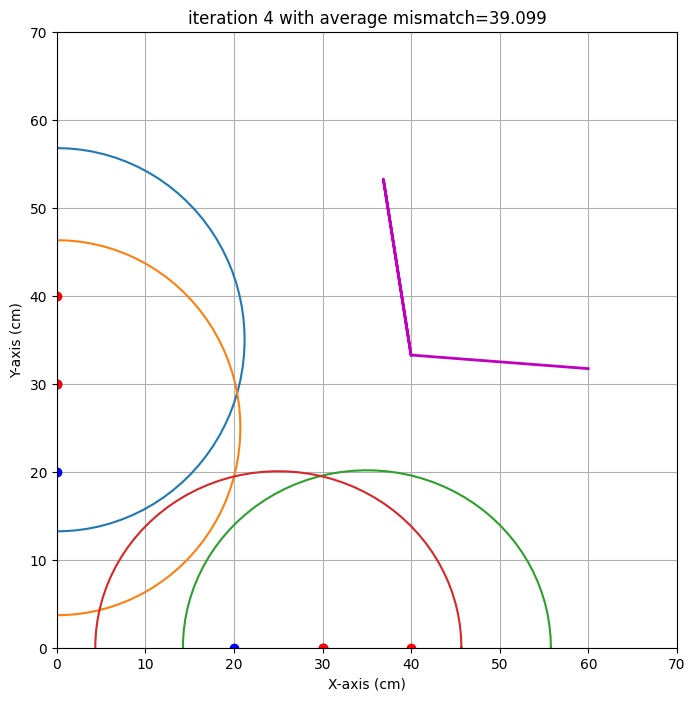

end iteration 4 with average mismatch=39.099


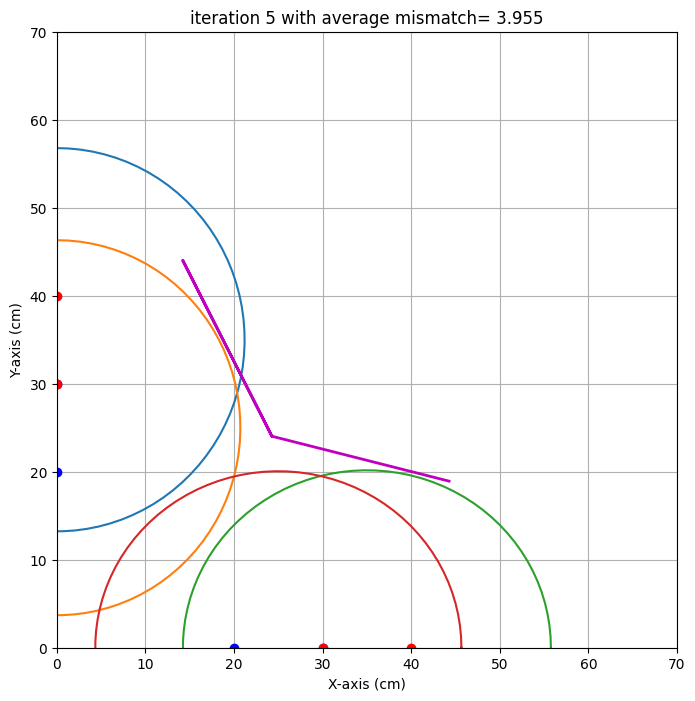

end iteration 5 with average mismatch= 3.955


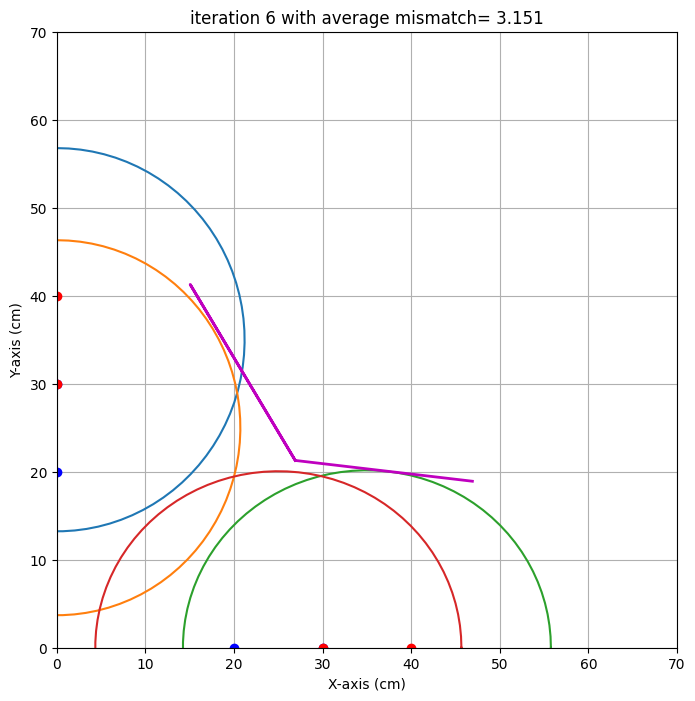

end iteration 6 with average mismatch= 3.151


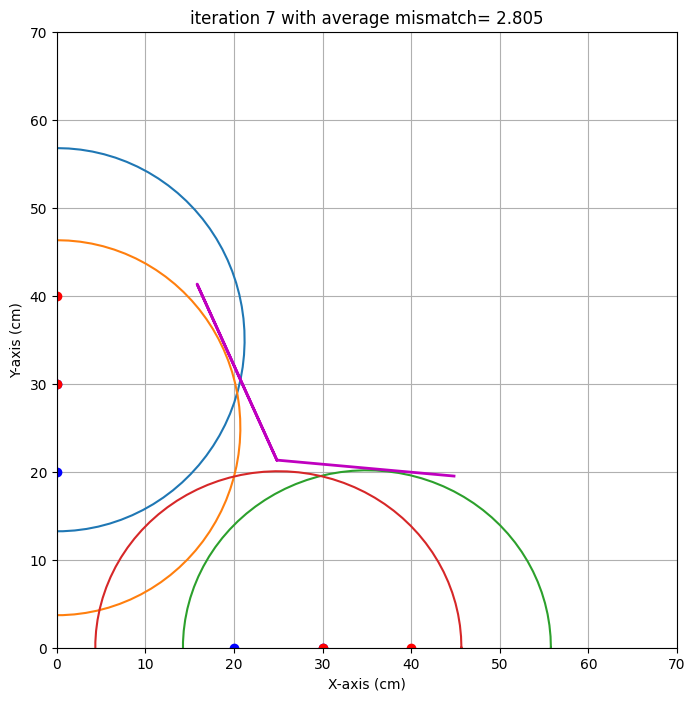

end iteration 7 with average mismatch= 2.805


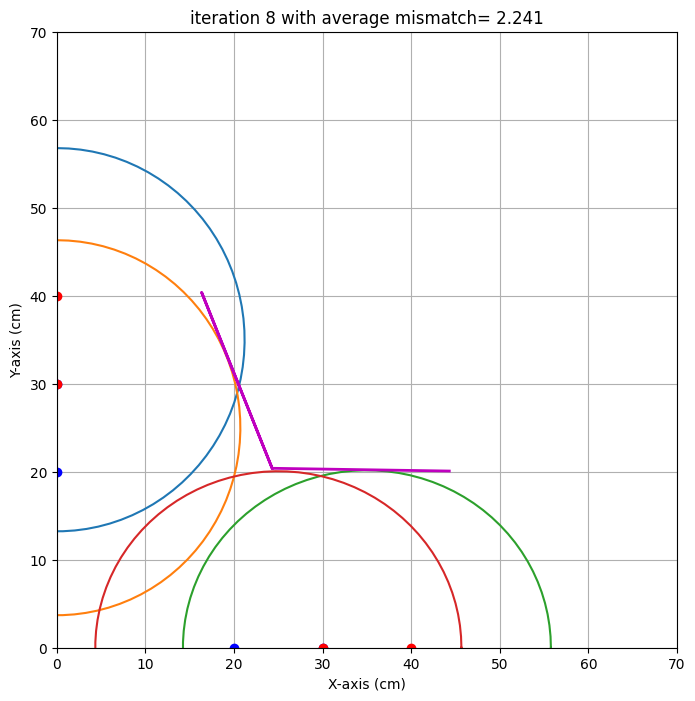

end iteration 8 with average mismatch= 2.241


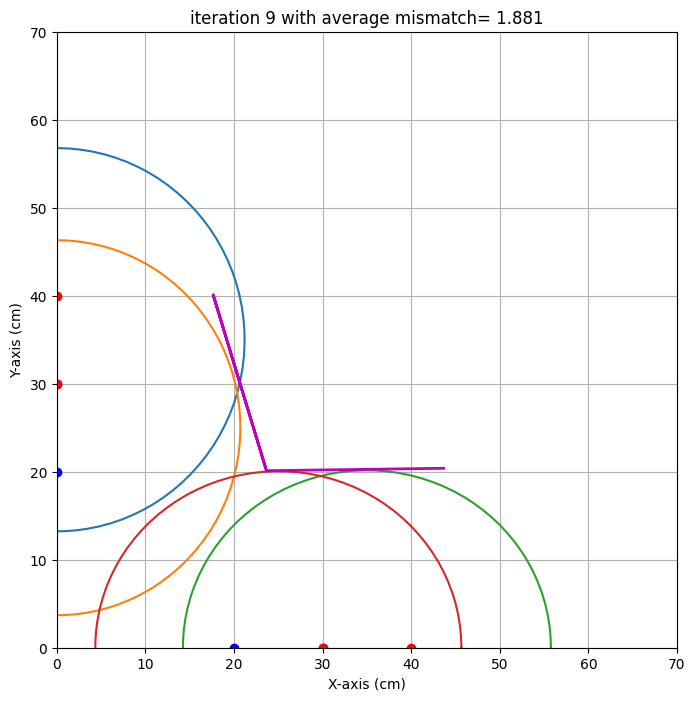

end iteration 9 with average mismatch= 1.881
end iteration 10 with average mismatch= 1.832
end iteration 11 with average mismatch= 1.832


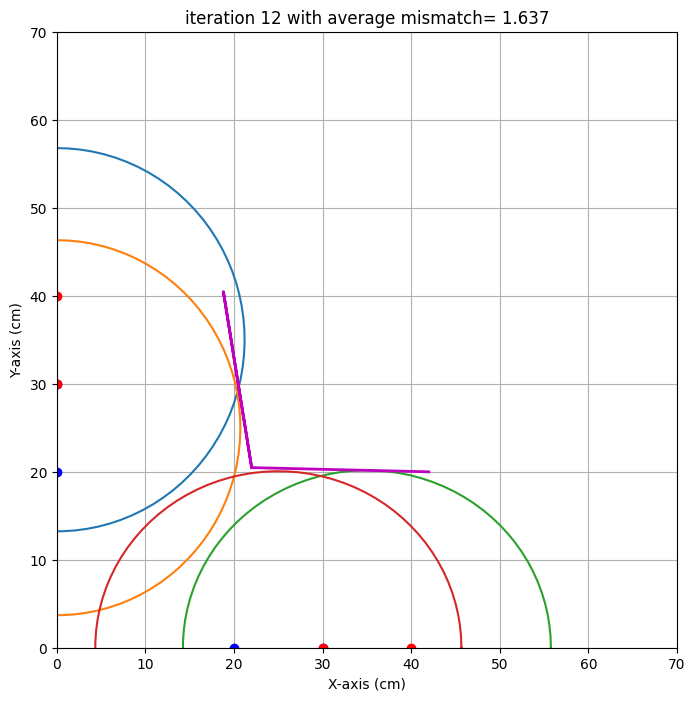

end iteration 12 with average mismatch= 1.637


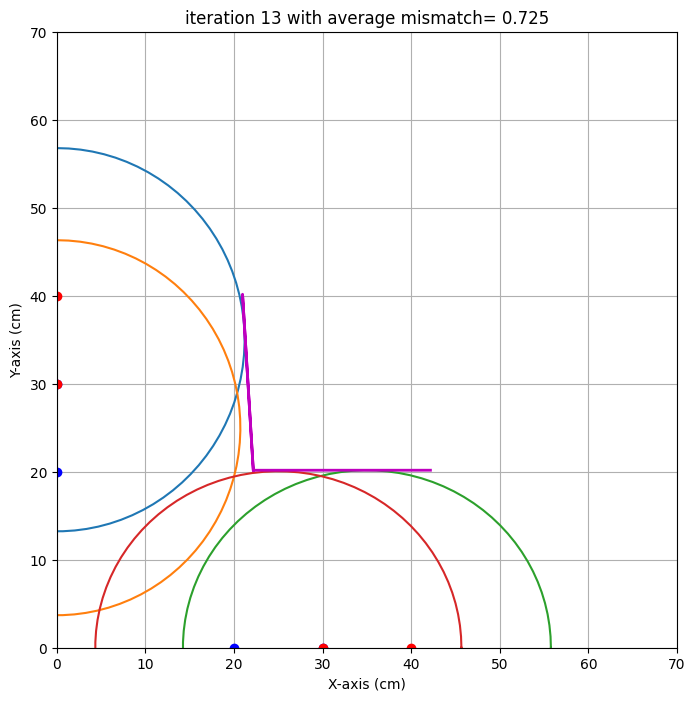

end iteration 13 with average mismatch= 0.725


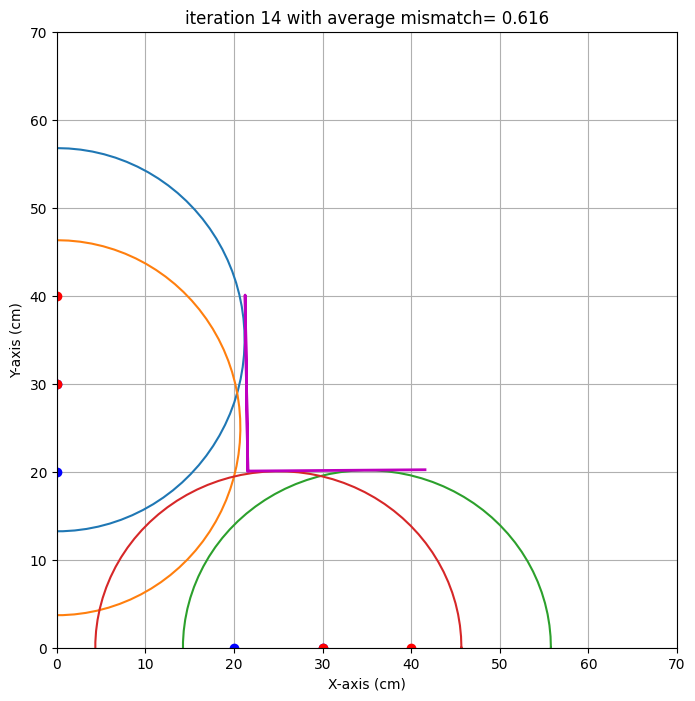

end iteration 14 with average mismatch= 0.616


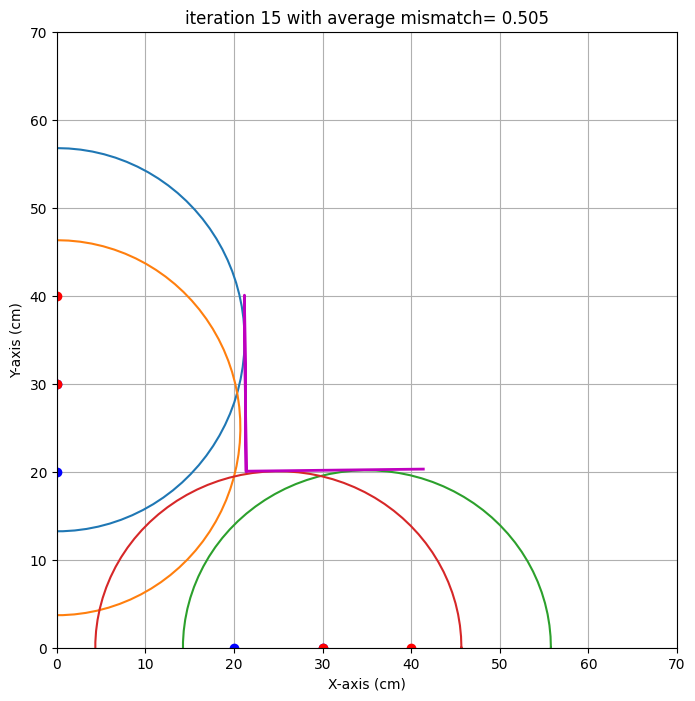

end iteration 15 with average mismatch= 0.505
end iteration 16 with average mismatch= 0.474
end iteration 17 with average mismatch= 0.464


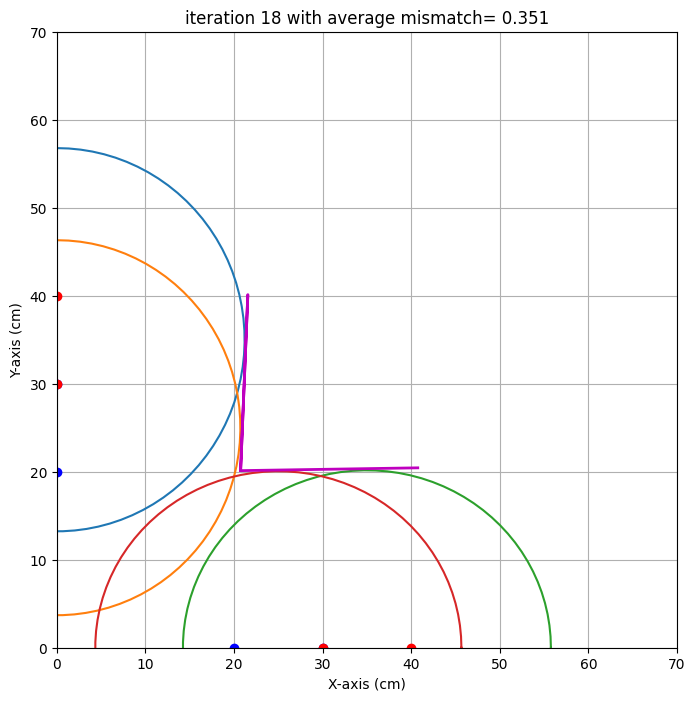

end iteration 18 with average mismatch= 0.351


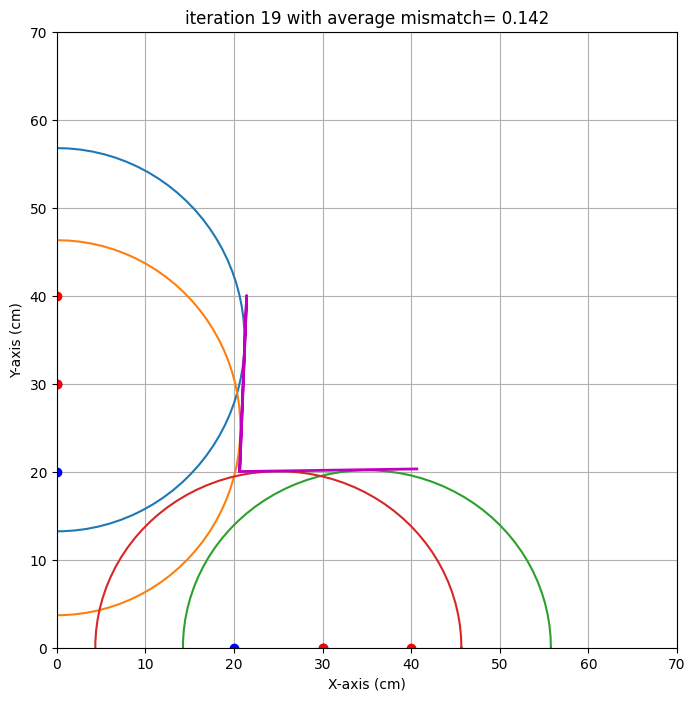

end iteration 19 with average mismatch= 0.142


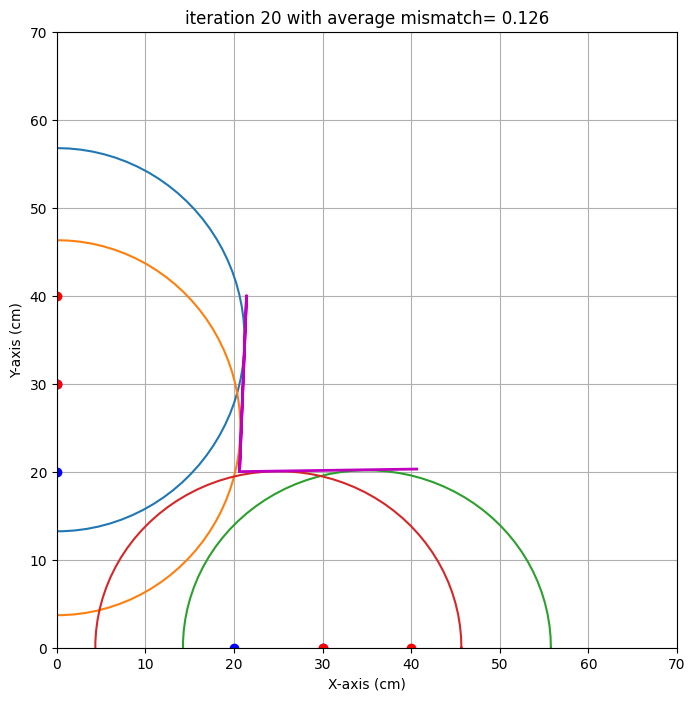

end iteration 20 with average mismatch= 0.126
end iteration 21 with average mismatch= 0.121
end iteration 22 with average mismatch= 0.120
end iteration 23 with average mismatch= 0.119
end iteration 24 with average mismatch= 0.117
end iteration 25 with average mismatch= 0.117
end iteration 26 with average mismatch= 0.117
end iteration 27 with average mismatch= 0.117
end iteration 28 with average mismatch= 0.117
end iteration 29 with average mismatch= 0.117
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.117
###############################################################################
end of iteration  30
Best alpha=   0.83 with uncertainty=   1.10
Best beta =   2.26 with uncertainty=   0.16
Best x0   =  20.61 with uncertainty=   0.13
Best y0   =  20.00 with uncertainty=   0.01
##########################################################

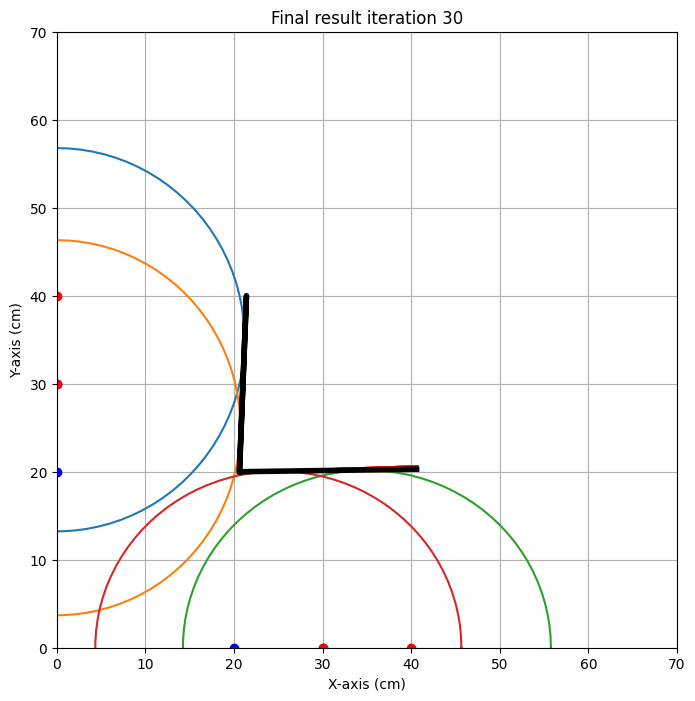

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,43.55],
    [0,30,0,20,42.62],
    #[0,10,0,20,3.0,170.63],
    [40,0,30,0,41.55],
    [30,0,20,0,41.34],
    #[10,0,20,0,153.37],
    #[10,0,0,10,127.64]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.6 cm met een standaardafwijking van 0.1 cm 
y0: 20.0 cm met een standaardafwijking van 0.0 cm 
alpha: 0.8 graden met een standaardafwijking van 1.1 graad 
beta: 2.3 graden met een standaardafwijking van 0.2 graad 



## Opdracht 5: Iteratie 0

#### algoritme Thomas Haak
Voeg een foto in van het algoritme van het eerste groepslid
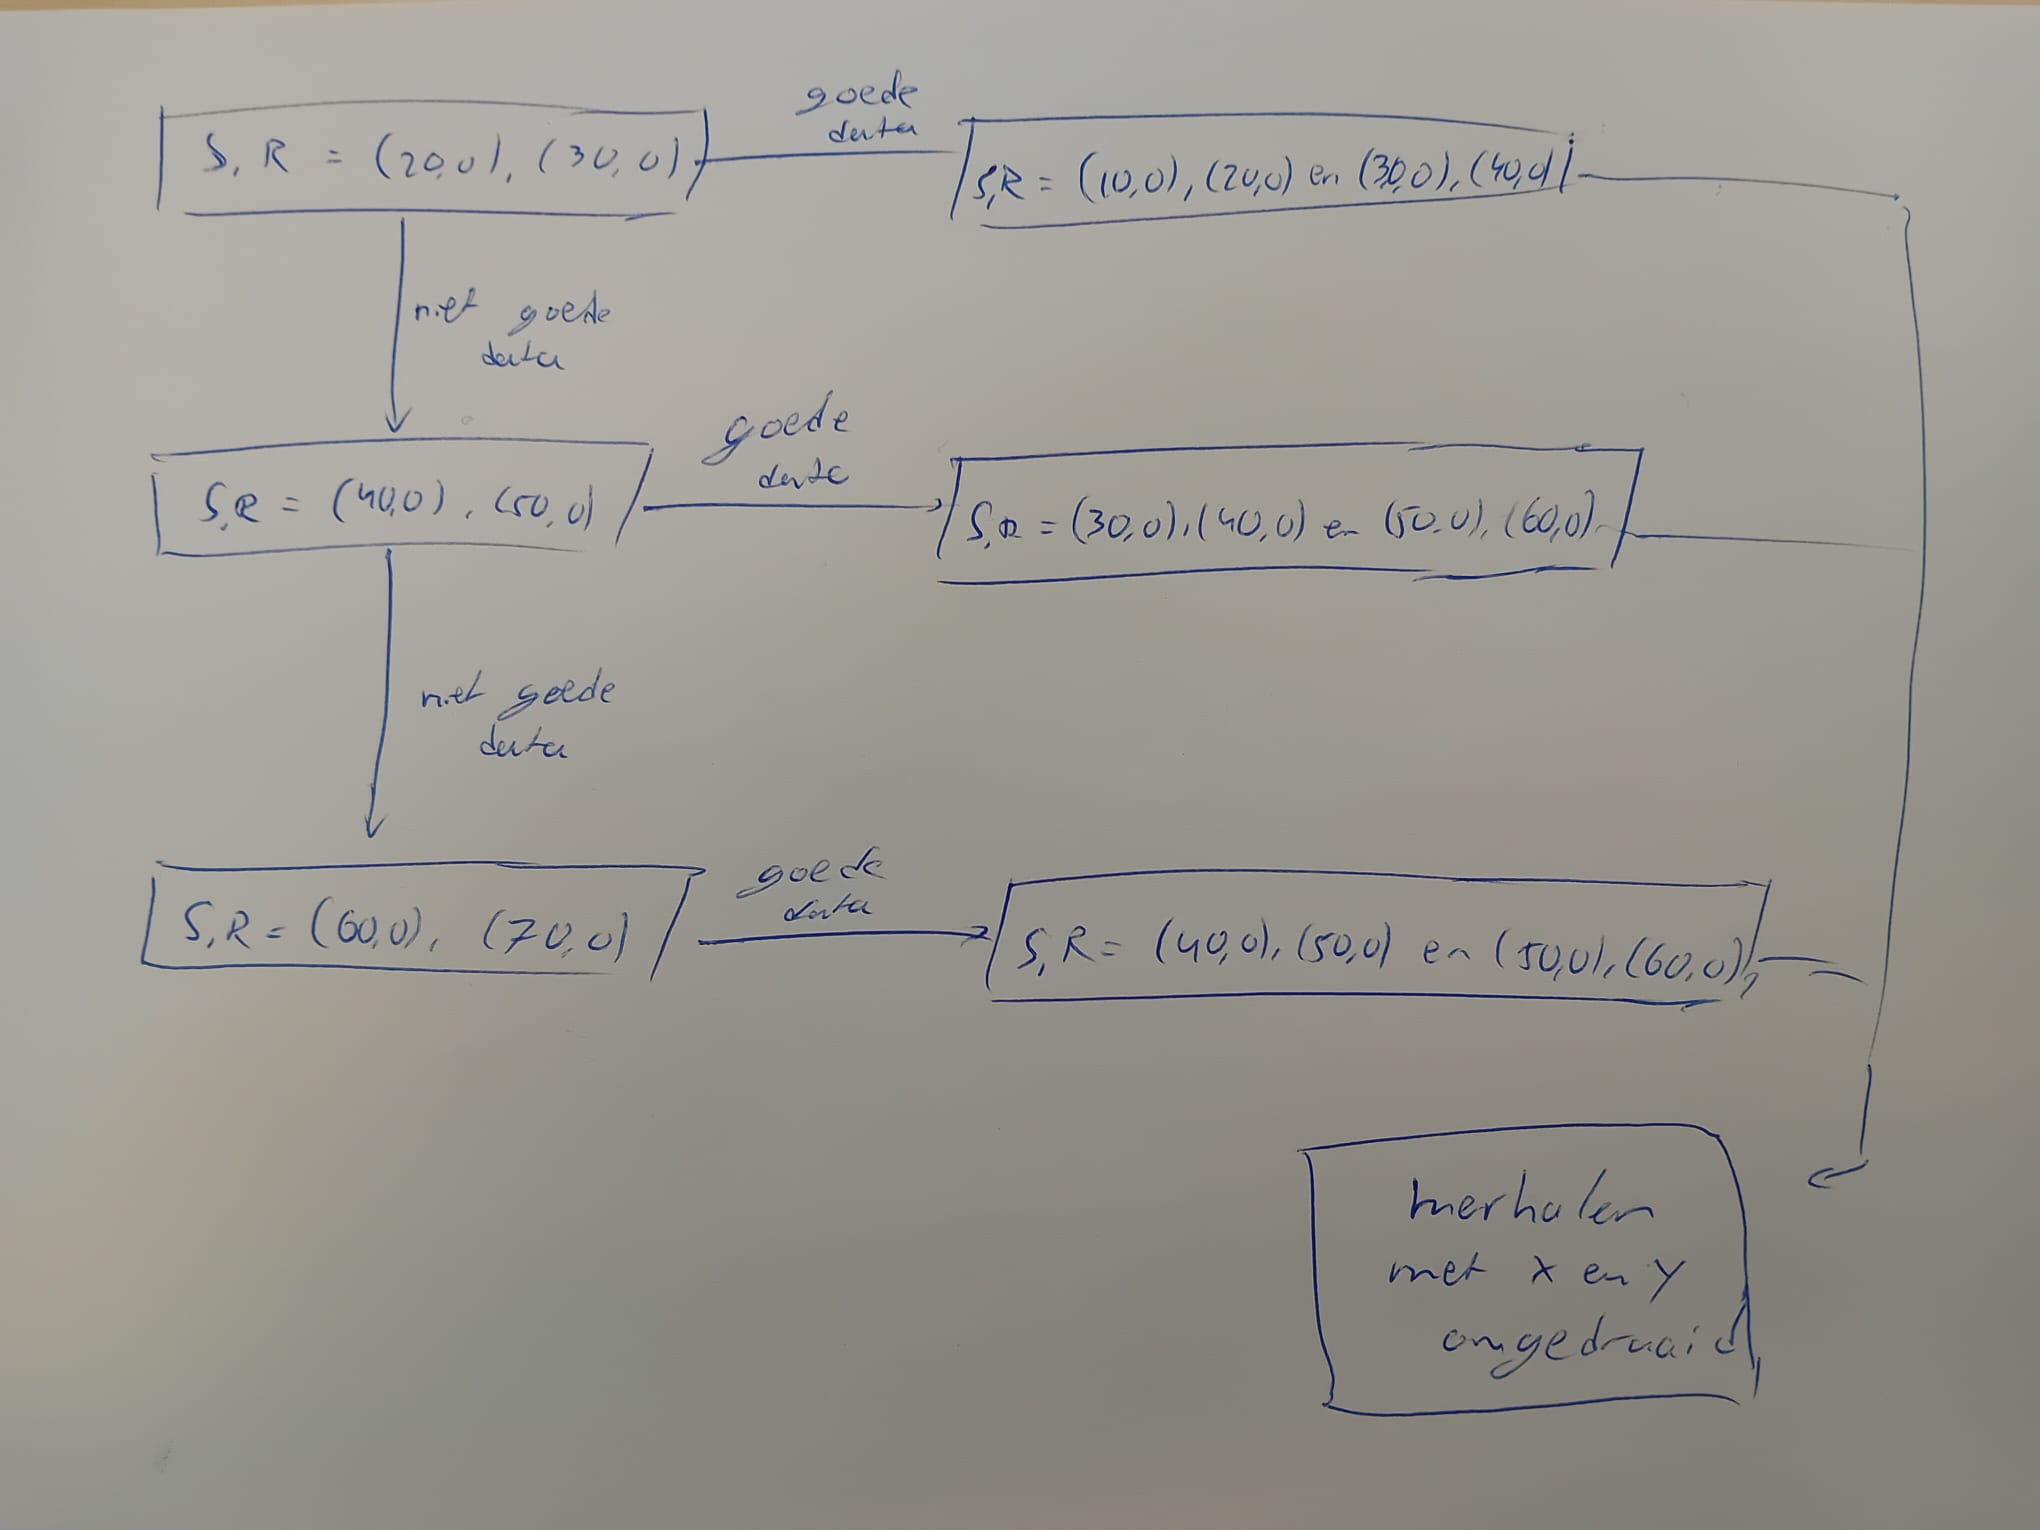

#### algoritme Matthias Grablowitz
Voeg een foto in van het algoritme van het tweede groepslid
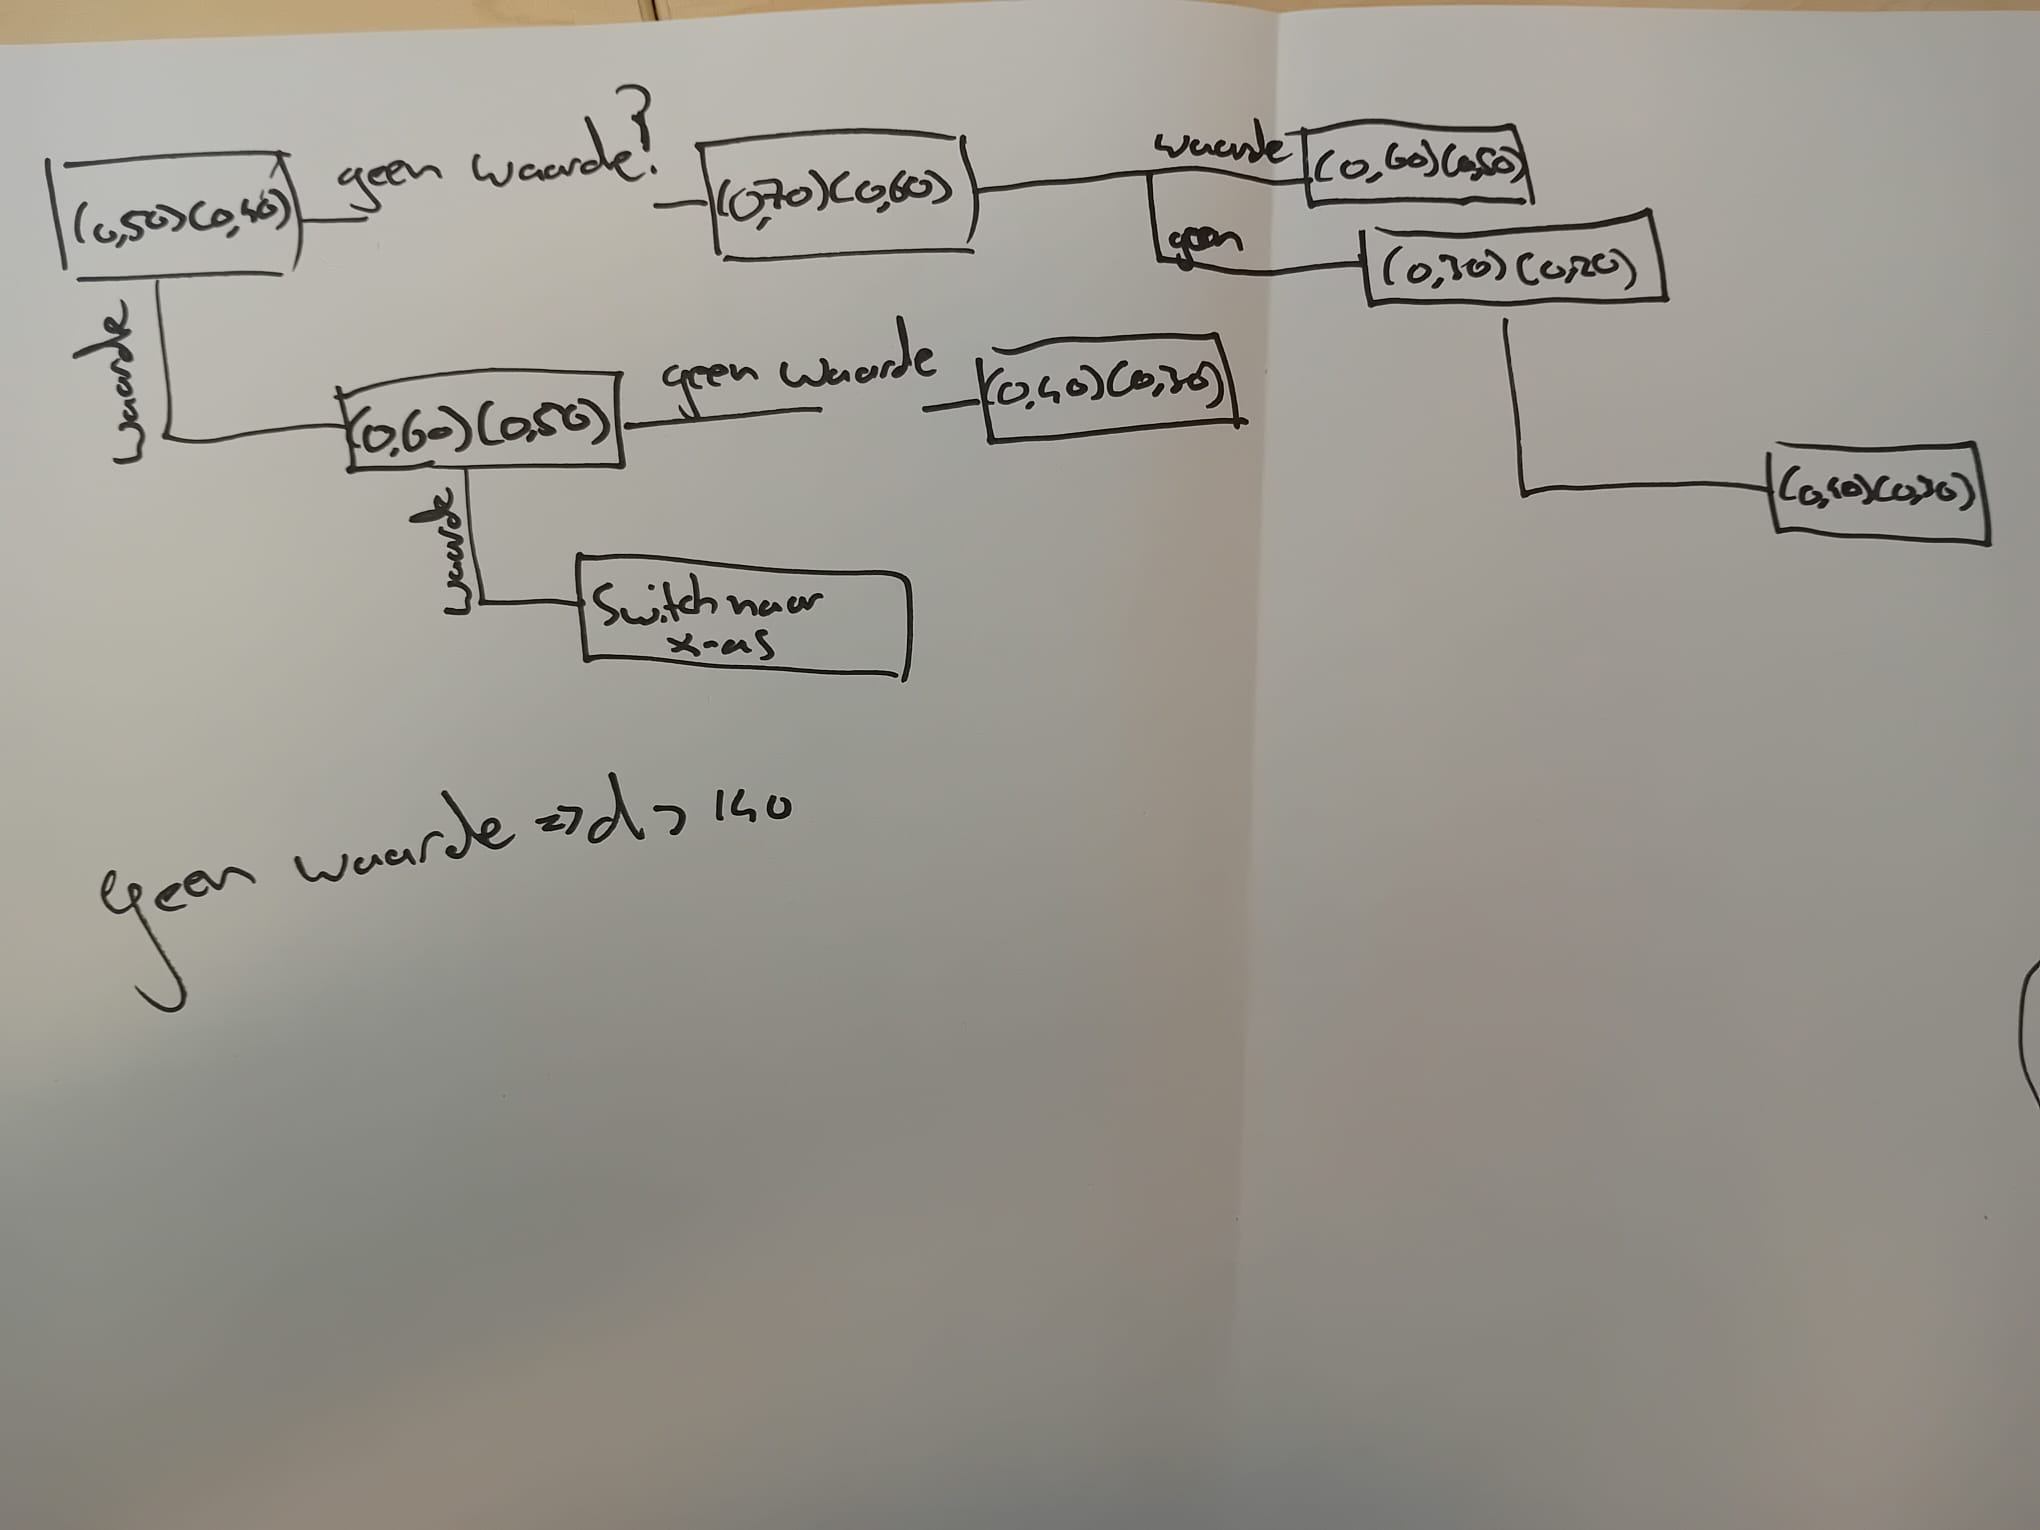

#### algoritme Chinming Zhu
Voeg een foto in van het algoritme van het derde groepslid
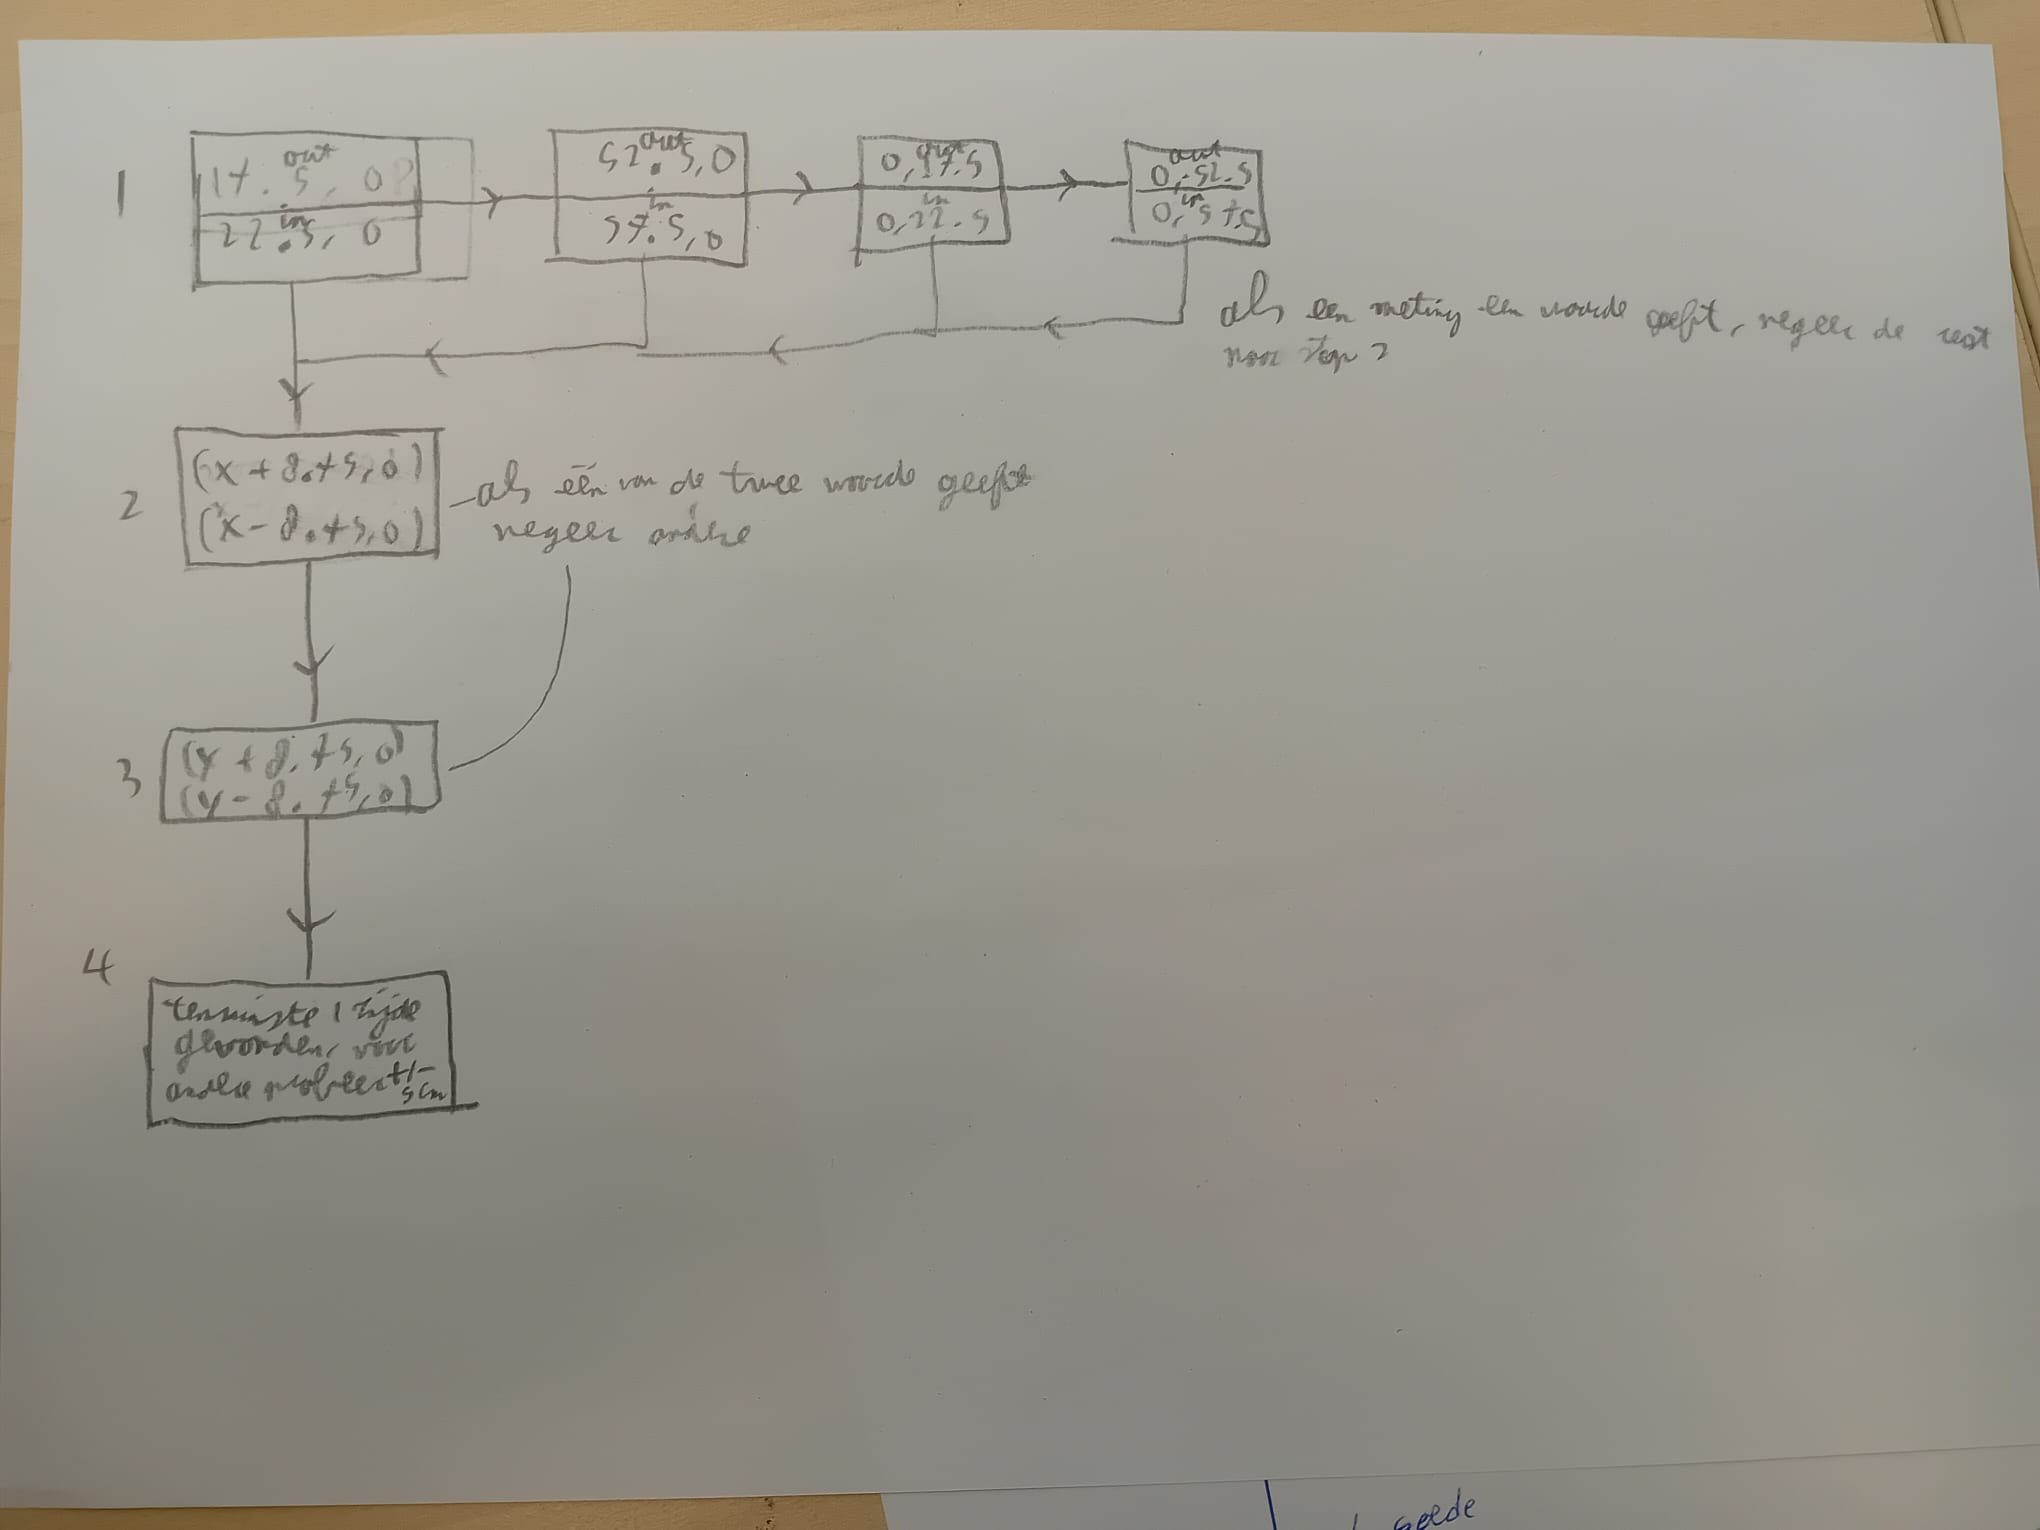

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!
# NVT

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':  25,
           'y0': 41,
           'alpha' : 4,
           'beta' : -4,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Thomas Haak' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20,0,30,0,85.12],
    #[10,0,20,0,144],
    [30,0,40,0,82.9],
    #[0,20,0,30,190],
    [0,40,0,50,49.62],
    #[0,30,0,40,151],
    [0,50,0,50,47.76]
    ]),
       'Matthias Grablowitz' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,50,0,40,49.31],
    [0,60,0,50,46.4],
    [50,0,40,0,84.12],
    [60,0,50,0,89.36],
    ]),
       'Chinming Zhu' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,17.5,0,22.5,180],
    [0,52.5,0,57.5,45.8],
    [0,61.25,0,66.25,46.3],
    #[17.5,0,22.5,0,169],
    [52.5,0,57.5,0,89.5],
    #[61.25,0,66.25,0,150],
    [43.75,0,48.75,0,84]
    ])
      }

## Opdracht 7: Evaluatie.

Thomas Haak
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  20   0  30   0  85.12
1  30   0  40   0  82.90
2   0  40   0  50  49.62
3   0  50   0  50  47.76


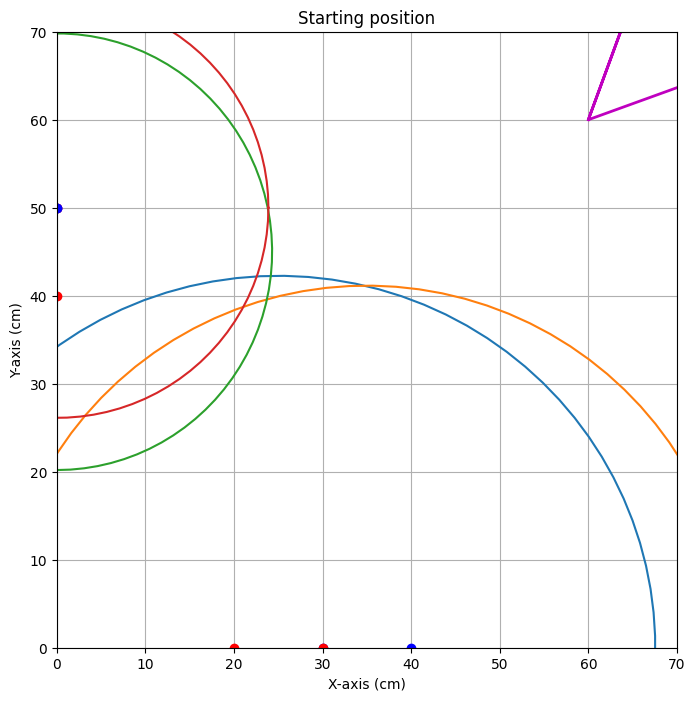


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.606


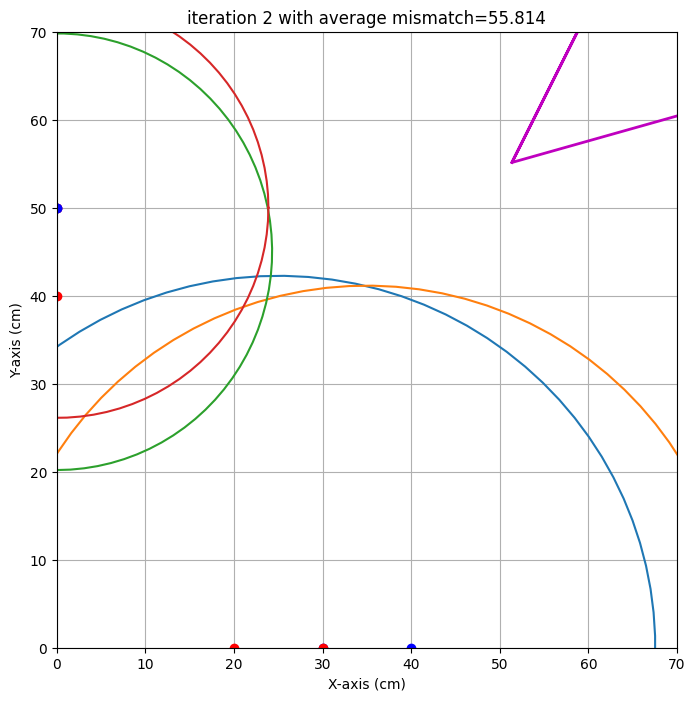

end iteration 2 with average mismatch=55.814


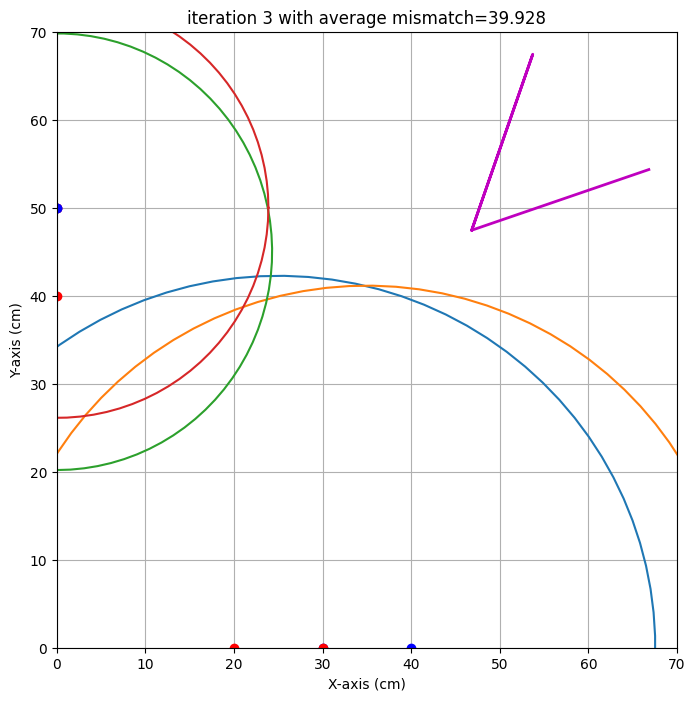

end iteration 3 with average mismatch=39.928


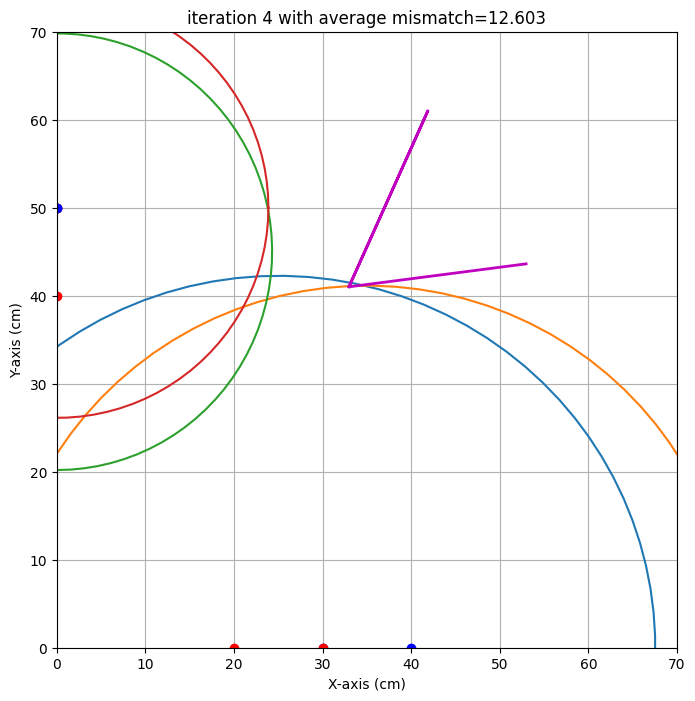

end iteration 4 with average mismatch=12.603


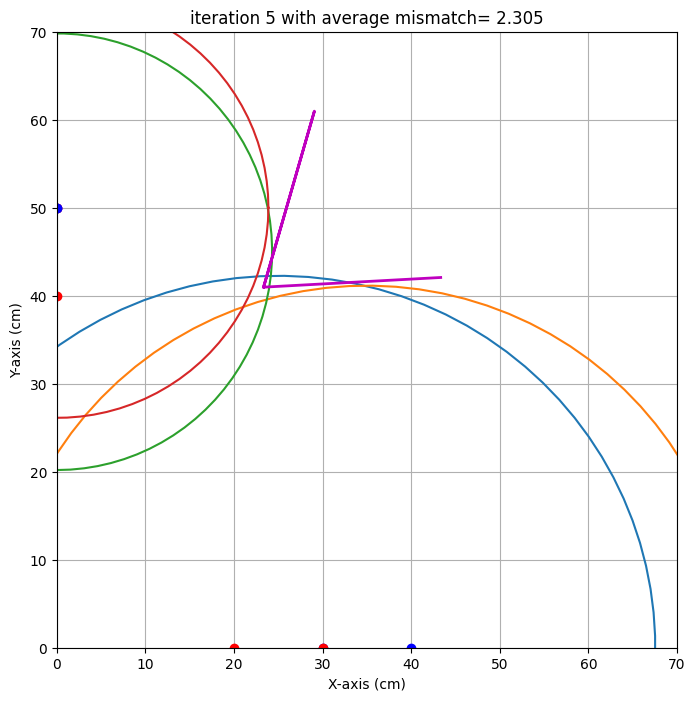

end iteration 5 with average mismatch= 2.305


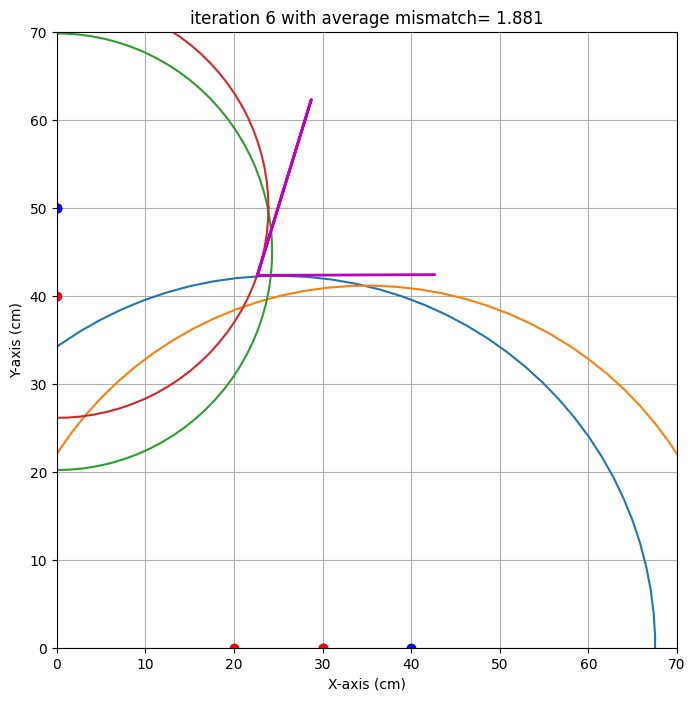

end iteration 6 with average mismatch= 1.881
end iteration 7 with average mismatch= 1.825


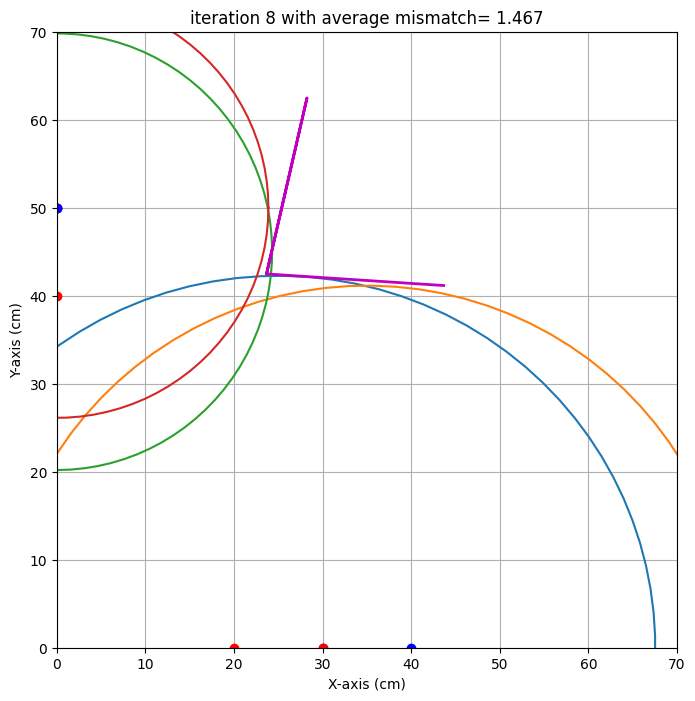

end iteration 8 with average mismatch= 1.467


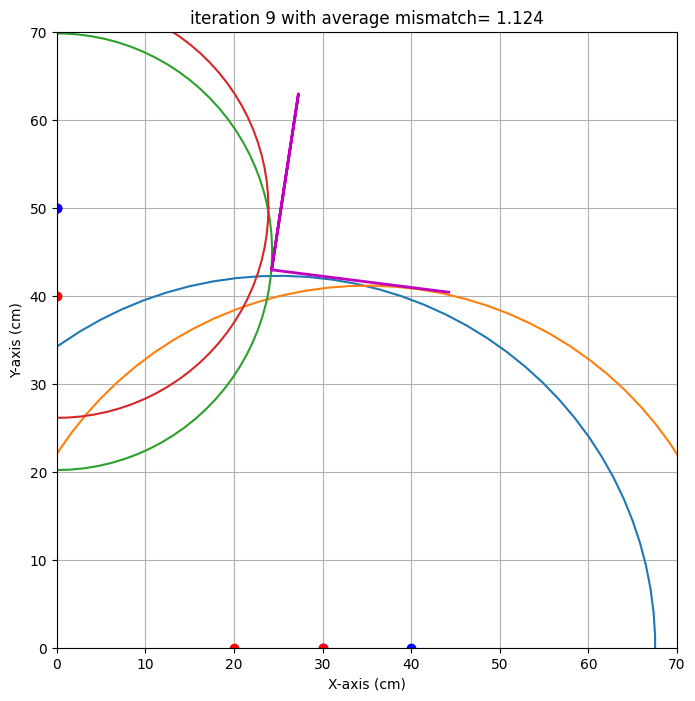

end iteration 9 with average mismatch= 1.124
end iteration 10 with average mismatch= 1.078


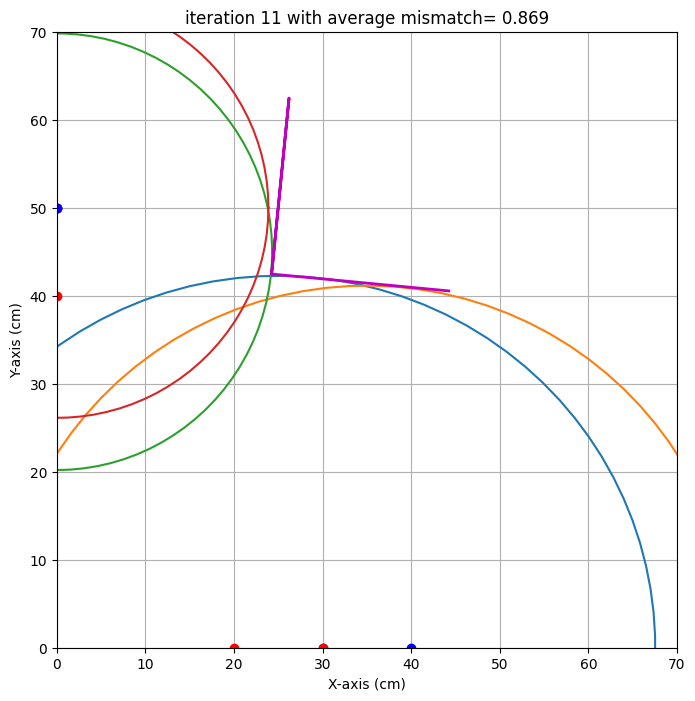

end iteration 11 with average mismatch= 0.869


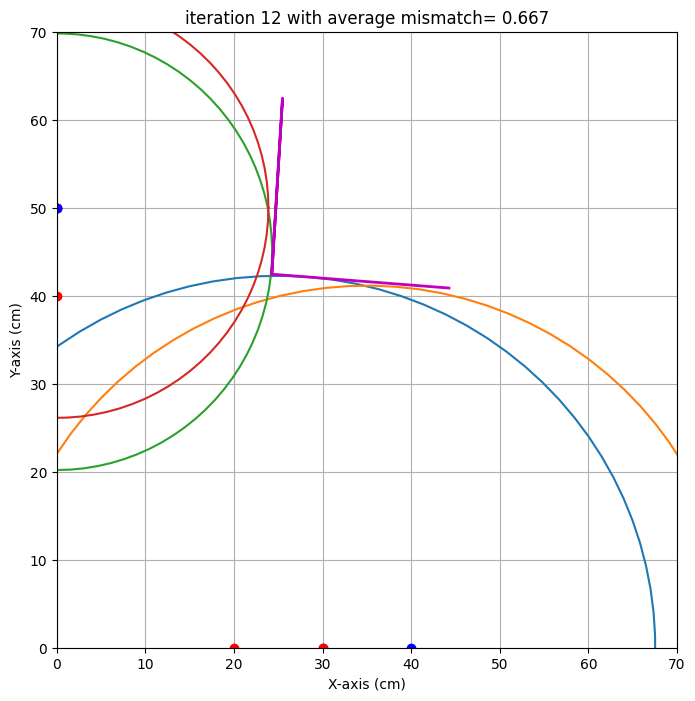

end iteration 12 with average mismatch= 0.667
end iteration 13 with average mismatch= 0.664
end iteration 14 with average mismatch= 0.622


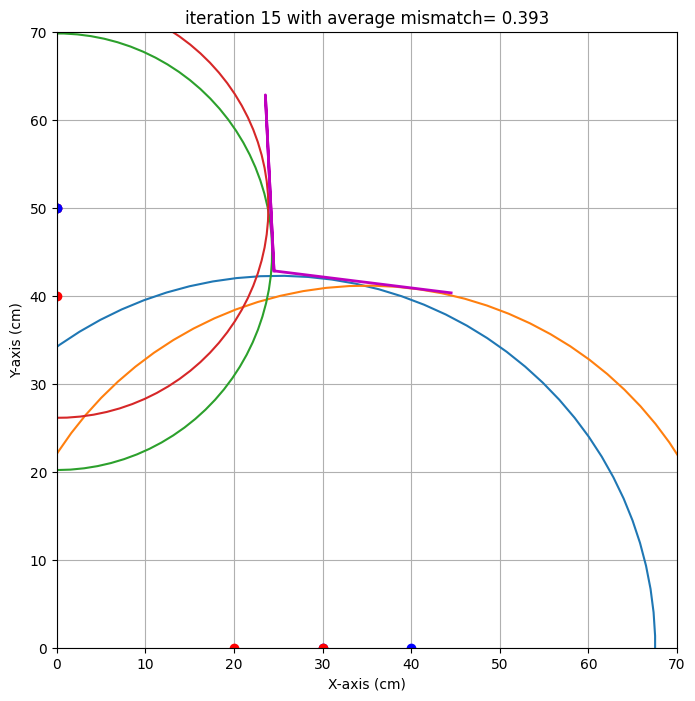

end iteration 15 with average mismatch= 0.393


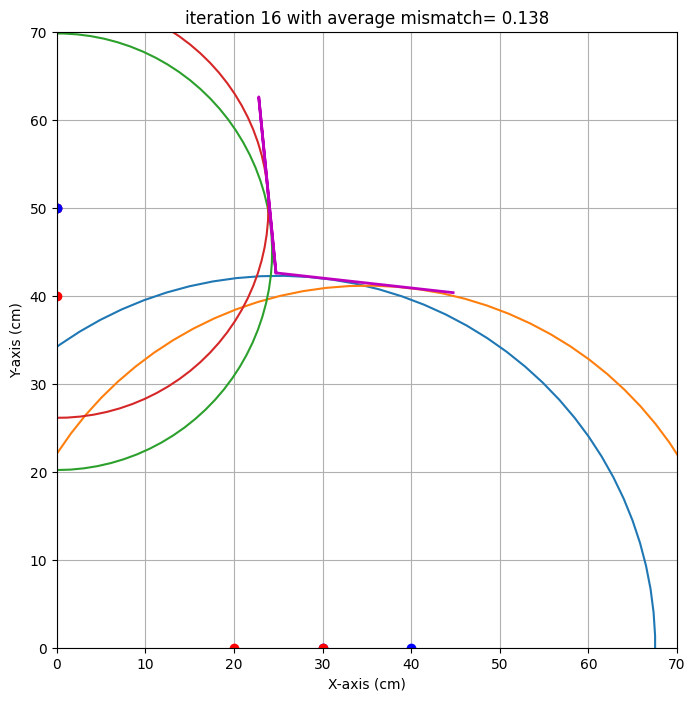

end iteration 16 with average mismatch= 0.138


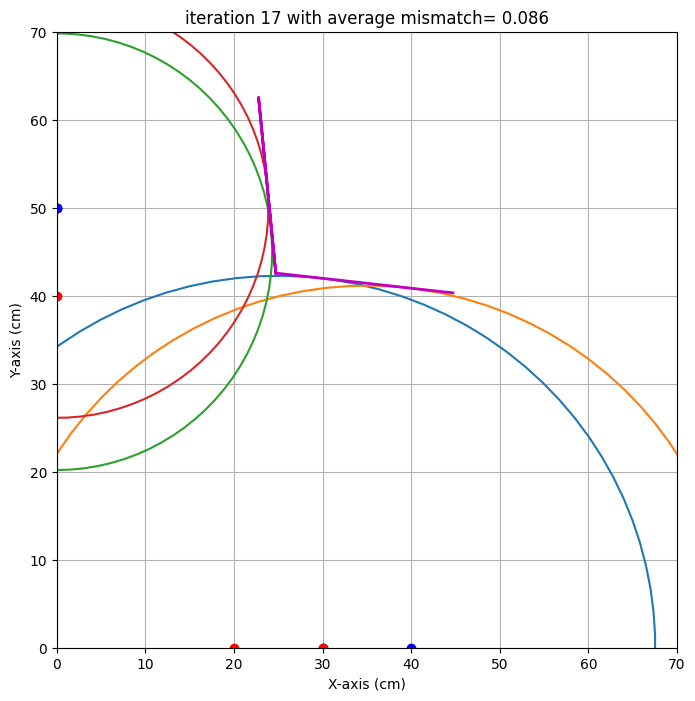

end iteration 17 with average mismatch= 0.086
end iteration 18 with average mismatch= 0.083
end iteration 19 with average mismatch= 0.083
end iteration 20 with average mismatch= 0.083
end iteration 21 with average mismatch= 0.083
end iteration 22 with average mismatch= 0.083
end iteration 23 with average mismatch= 0.083
end iteration 24 with average mismatch= 0.083
end iteration 25 with average mismatch= 0.083
end iteration 26 with average mismatch= 0.083
end iteration 27 with average mismatch= 0.083
end iteration 28 with average mismatch= 0.083
end iteration 29 with average mismatch= 0.083
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.083
###############################################################################
end of iteration  30
Best alpha=  -6.41 with uncertainty=   2.32
Best beta =  -5.57 with uncertainty=   1.61
Best x0   =  24.71 with uncertainty=   0.26
Best y0   =  4

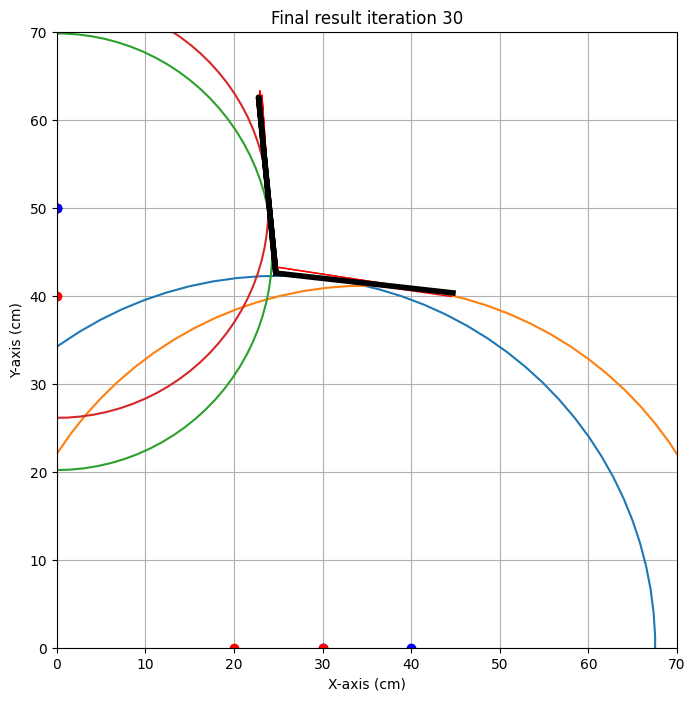

{'alpha': np.float64(-6.411345923902979), 'alpha_eps': np.float64(2.323532958972046), 'beta': np.float64(-5.5718724881057415), 'beta_eps': np.float64(1.6070431415558817), 'x0': np.float64(24.71173850704274), 'x0_eps': np.float64(0.26238069790655416), 'y0': np.float64(42.56822409625343), 'y0_eps': np.float64(0.728009639874756)}
Matthias Grablowitz
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  50   0  40  49.31
1   0  60   0  50  46.40
2  50   0  40   0  84.12
3  60   0  50   0  89.36


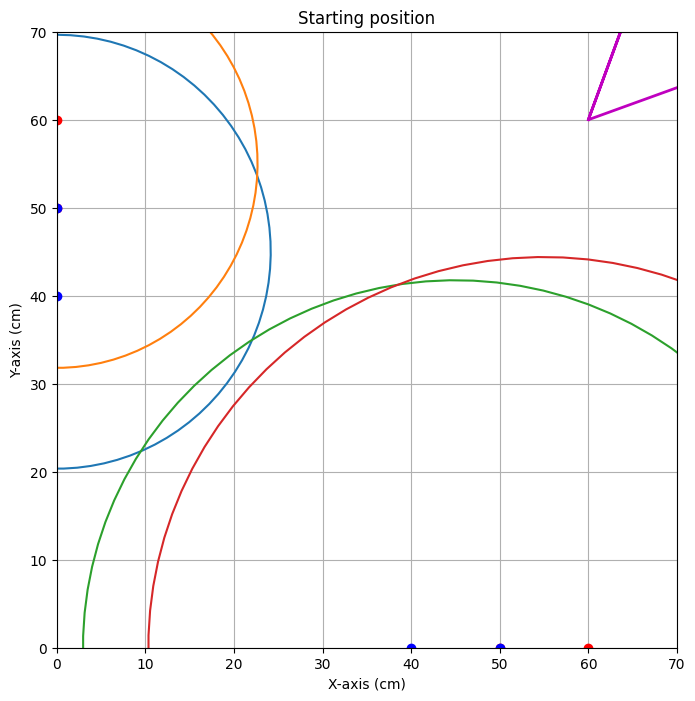


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.275


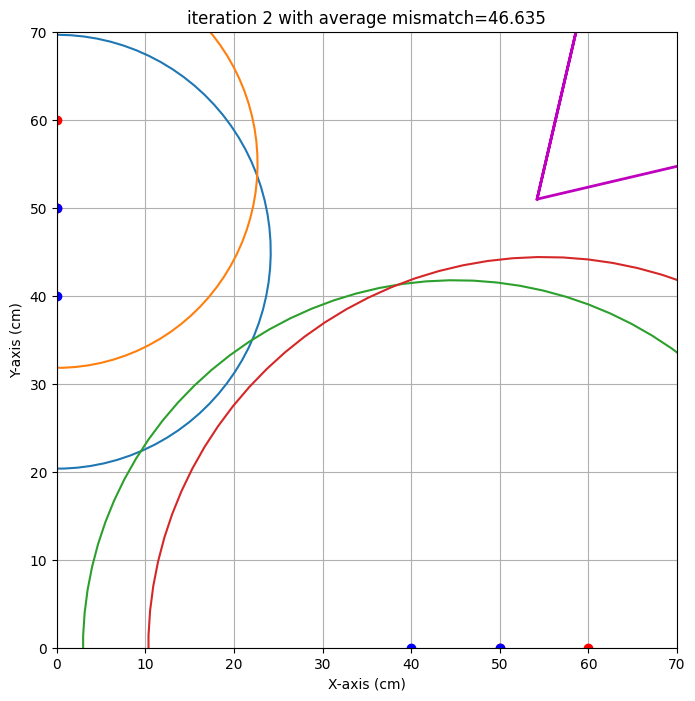

end iteration 2 with average mismatch=46.635


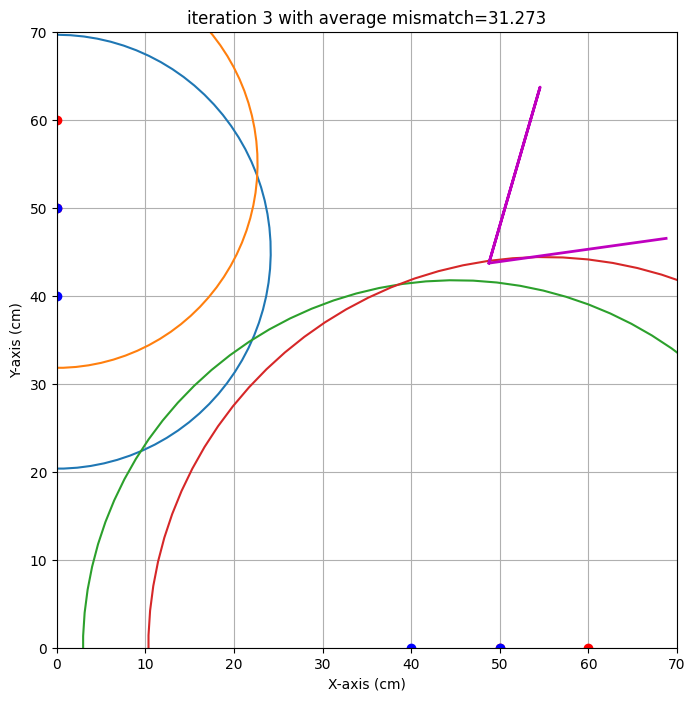

end iteration 3 with average mismatch=31.273


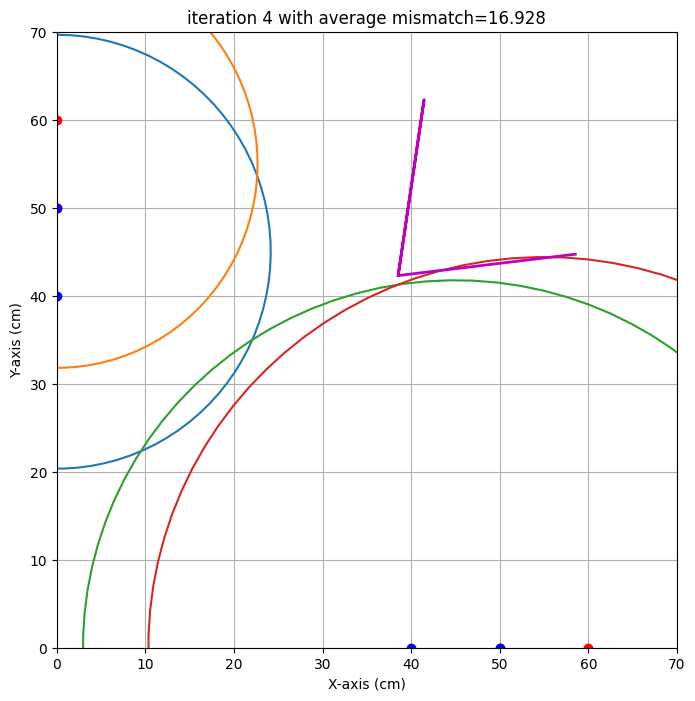

end iteration 4 with average mismatch=16.928


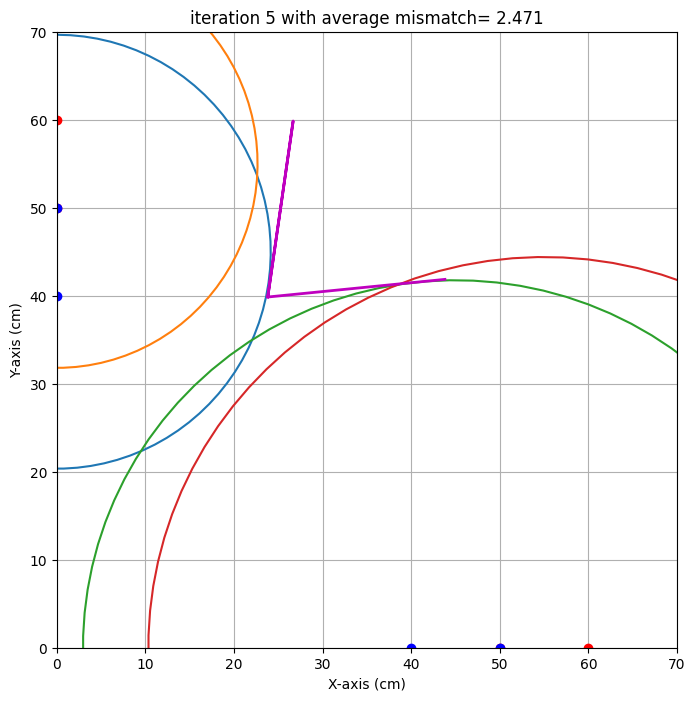

end iteration 5 with average mismatch= 2.471


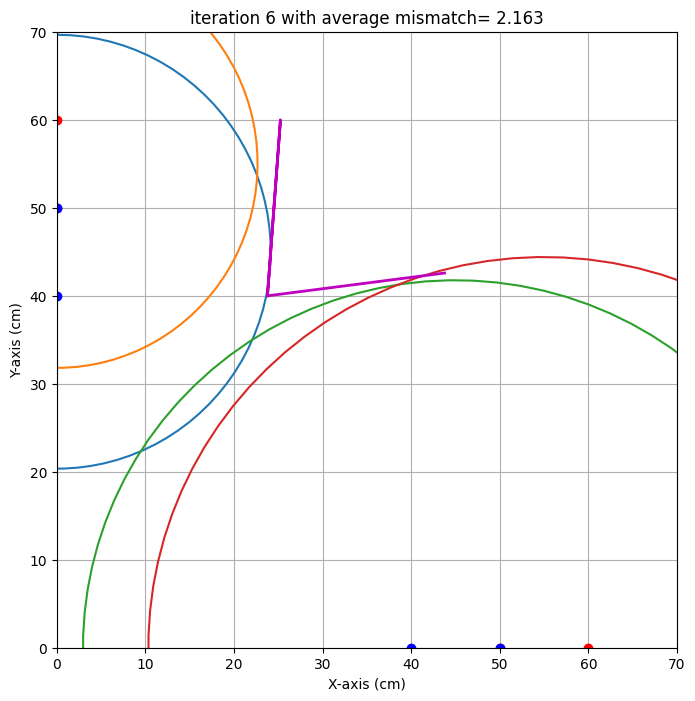

end iteration 6 with average mismatch= 2.163


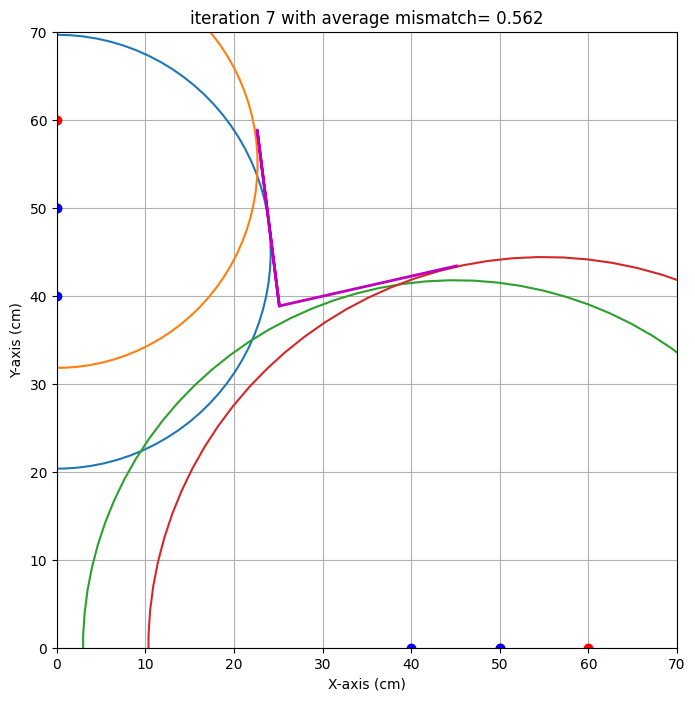

end iteration 7 with average mismatch= 0.562
end iteration 8 with average mismatch= 0.553
end iteration 9 with average mismatch= 0.551
end iteration 10 with average mismatch= 0.550
end iteration 11 with average mismatch= 0.550
end iteration 12 with average mismatch= 0.550
end iteration 13 with average mismatch= 0.550
end iteration 14 with average mismatch= 0.550
end iteration 15 with average mismatch= 0.550
end iteration 16 with average mismatch= 0.550
end iteration 17 with average mismatch= 0.550
end iteration 18 with average mismatch= 0.524
end iteration 19 with average mismatch= 0.514
end iteration 20 with average mismatch= 0.513
end iteration 21 with average mismatch= 0.513


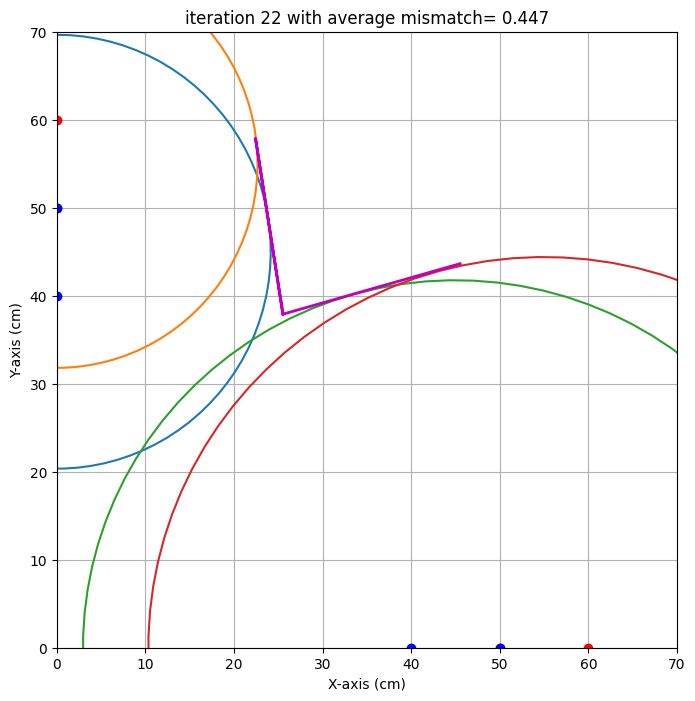

end iteration 22 with average mismatch= 0.447


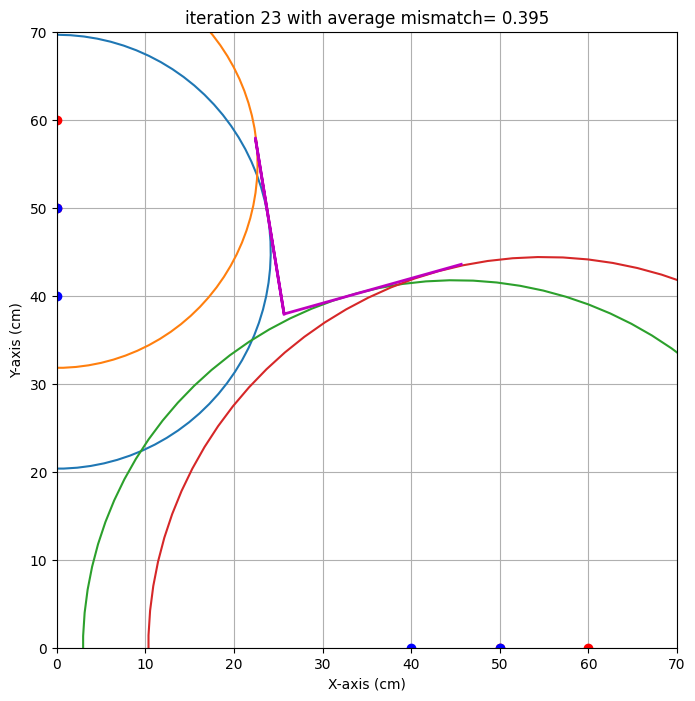

end iteration 23 with average mismatch= 0.395
end iteration 24 with average mismatch= 0.395
end iteration 25 with average mismatch= 0.395
end iteration 26 with average mismatch= 0.395
end iteration 27 with average mismatch= 0.395
end iteration 28 with average mismatch= 0.395
end iteration 29 with average mismatch= 0.395
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.395
###############################################################################
end of iteration  30
Best alpha=  15.75 with uncertainty=   3.31
Best beta =  -9.21 with uncertainty=   2.87
Best x0   =  25.65 with uncertainty=   0.61
Best y0   =  37.92 with uncertainty=   0.76
###############################################################################


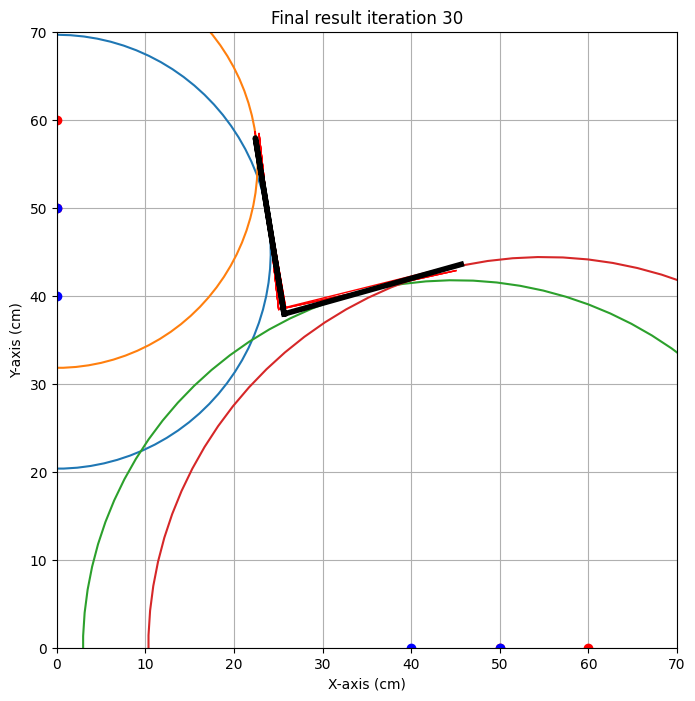

{'alpha': np.float64(15.752297087691744), 'alpha_eps': np.float64(3.313074192755158), 'beta': np.float64(-9.211986079667055), 'beta_eps': np.float64(2.8727669187442935), 'x0': np.float64(25.649507611284275), 'x0_eps': np.float64(0.609304001733971), 'y0': np.float64(37.92456629674283), 'y0_eps': np.float64(0.7560944648419081)}
Chinming Zhu
Running the imaging algorithm with the following data:
      xs     ys     xr     yr     R
0   0.00  52.50   0.00  57.50  45.8
1   0.00  61.25   0.00  66.25  46.3
2  52.50   0.00  57.50   0.00  89.5
3  43.75   0.00  48.75   0.00  84.0


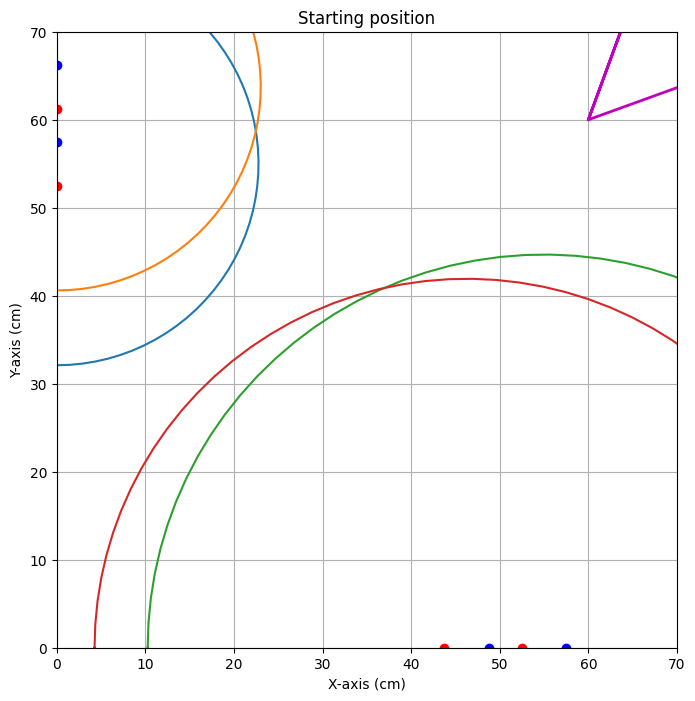


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.191


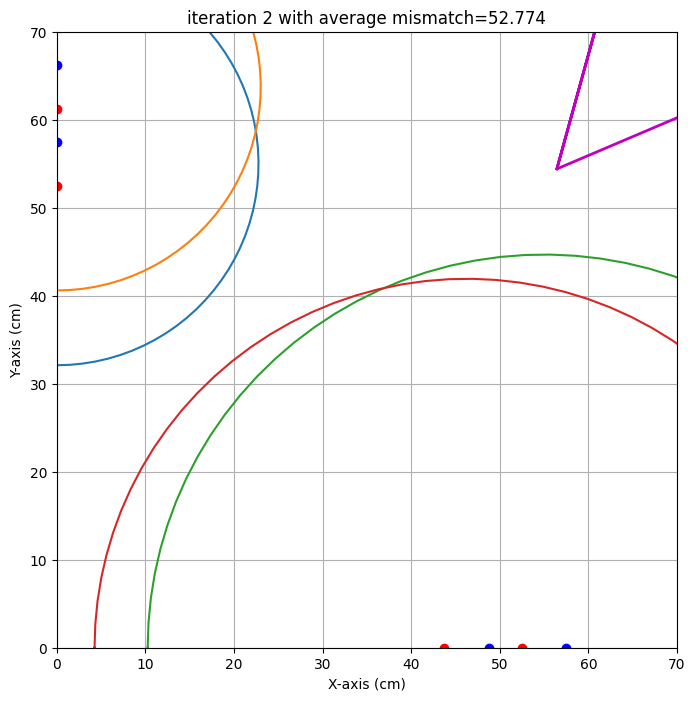

end iteration 2 with average mismatch=52.774


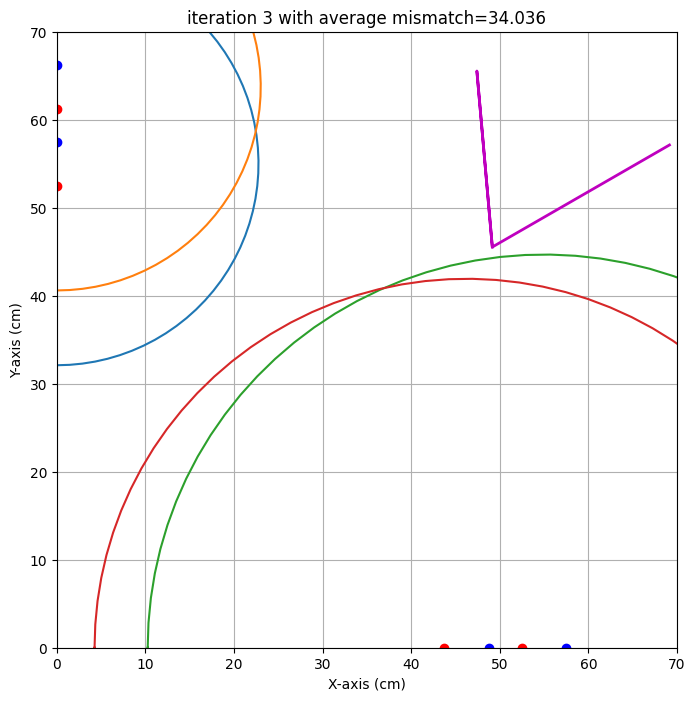

end iteration 3 with average mismatch=34.036


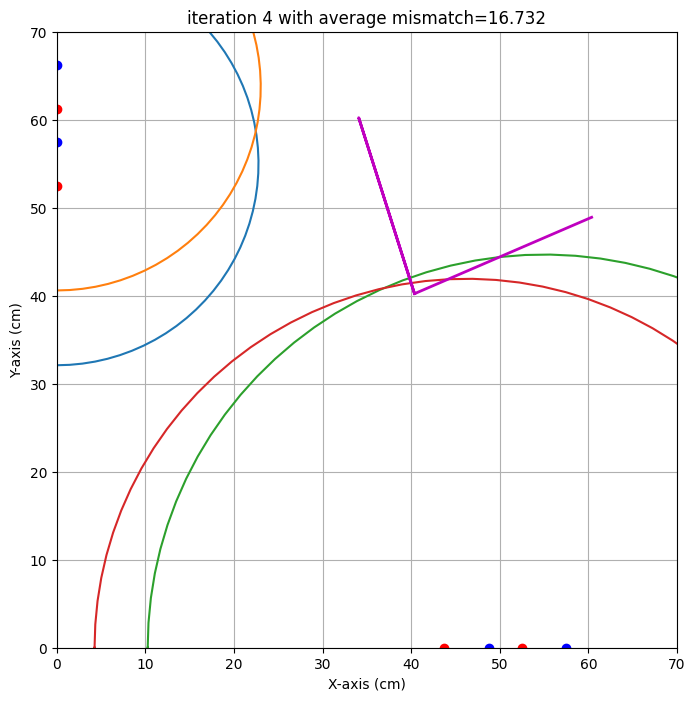

end iteration 4 with average mismatch=16.732


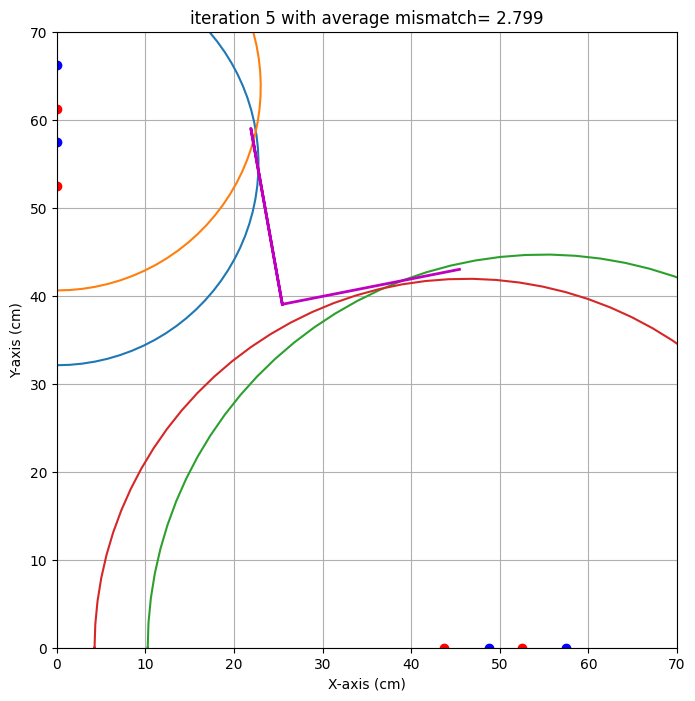

end iteration 5 with average mismatch= 2.799


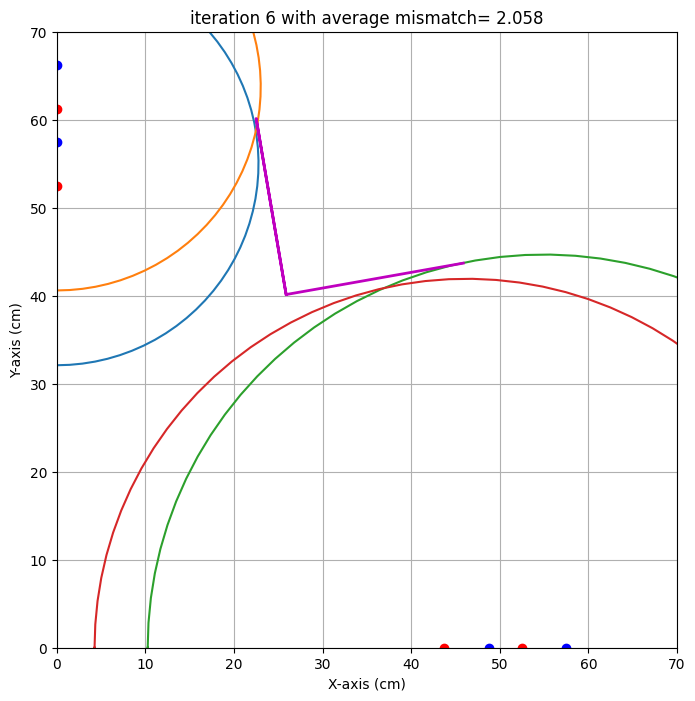

end iteration 6 with average mismatch= 2.058
end iteration 7 with average mismatch= 1.967
end iteration 8 with average mismatch= 1.916
end iteration 9 with average mismatch= 1.916
end iteration 10 with average mismatch= 1.823
end iteration 11 with average mismatch= 1.814
end iteration 12 with average mismatch= 1.786
end iteration 13 with average mismatch= 1.741
end iteration 14 with average mismatch= 1.738
end iteration 15 with average mismatch= 1.738
end iteration 16 with average mismatch= 1.738
end iteration 17 with average mismatch= 1.738
end iteration 18 with average mismatch= 1.738
end iteration 19 with average mismatch= 1.738
end iteration 20 with average mismatch= 1.738
end iteration 21 with average mismatch= 1.738
end iteration 22 with average mismatch= 1.738
end iteration 23 with average mismatch= 1.738
end iteration 24 with average mismatch= 1.738
end iteration 25 with average mismatch= 1.738
end iteration 26 with average mismatch= 1.738
end iteration 27 with average mismatch

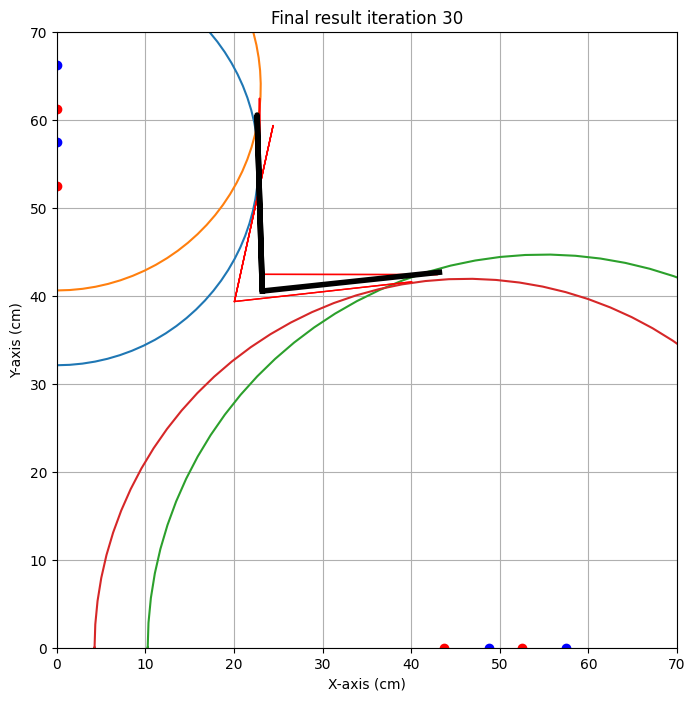

{'alpha': np.float64(6.097907501498229), 'alpha_eps': np.float64(6.177405723251521), 'beta': np.float64(-1.6690894048994926), 'beta_eps': np.float64(13.979285454897001), 'x0': np.float64(23.186316953865532), 'x0_eps': np.float64(3.1422664757582055), 'y0': np.float64(40.5299666332551), 'y0_eps': np.float64(1.899406457077717)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Thomas Haak 
x0 target is : 25.0. Gevonden waarde: 24.7 cm met een standaardafwijking van 0.3 cm 
y0 target is : 41.0. Gevonden waarde: 42.6 cm met een standaardafwijking van 0.7 cm 
alpha target is : 4.0. Gevonden waarde: -6.4 graden met een standaardafwijking van 2.3 graad 
beta target is : -4.0. Gevonden waarde: -5.6 graden met een standaardafwijking van 1.6 graad 

Matthias Grablowitz 
x0 target is : 25.0. Gevonden waarde: 25.6 cm met een standaardafwijking van 0.6 cm 
y0 target is : 41.0. Gevonden waarde: 37.9 cm met een standaardafwijking van 0.8 cm 
alpha target is : 4.0. Gevonden waarde: 15.8 graden met een standaardafwijking van 3.3 graad 
beta target is : -4.0. Gevonden waarde: -9.2 graden met een standaardafwijking van 2.9 graad 

Chinming Zhu 
x0 target is : 25.0. Gevonden waarde: 23.2 cm met een standaardafwijking van 3.1 cm 
y0 target is : 41.0. Gevonden waarde: 40.5 cm met een standaardafwijking van 1.9 cm 
alpha target is : 4.0. Gevonden waarde: 6.1 graden met een stand

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](tudelftLogo.png)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen},
           'locatie 2':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: '{' was never closed (786680266.py, line 4)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (598375666.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")